# 🩺 Diabetes Risk Classification — End-to-End Machine Learning Project

<div align="center">

**Dataset:** CDC Behavioral Risk Factor Surveillance System (BRFSS) · **253,680 survey responses**

</div>

---

**👨‍💻 Author:** Saikat Sarkar &nbsp;|&nbsp; 🎓 Indian Institute of Technology, Jodhpur &nbsp;|&nbsp; 📊 Data Science & AI

---

This notebook presents a complete machine learning pipeline for **binary classification of Diabetes risk** using real-world CDC health survey data. We walk through every stage of the data science workflow — from raw data ingestion and exploratory analysis through feature engineering, model training, hyperparameter tuning, and final model evaluation.

---

### 🎯 Project Objective
Predict whether a respondent has **Diabetes** (`1`) or **No Diabetes** (`0`) based on 21 behavioral and clinical health indicators. This is a high-stakes healthcare classification problem where **minimizing missed diabetes cases (False Negatives)** is the primary clinical objective.

### 📌 Notebook Structure
| # | Stage | Description |
|---|-------|-------------|
| 1 | Setup & Imports | Libraries, theme configuration |
| 2–5 | Data Loading & Inspection | Schema, types, cardinality |
| 6–9 | Preprocessing | Type casting, label encoding |
| 10–12 | EDA | Distributions, bivariate analysis |
| 13 | Outlier Analysis | IQR strategy & medical reasoning |
| 14 | VIF Analysis | Multicollinearity check |
| 15–16 | Model Pipeline | SMOTE, train-test split, tuning helpers |
| 17–23 | Model Training | DT, RF, KNN, SVM, GB, XGB, Stacking |
| 24–28 | Model Evaluation | ROC-AUC, PR Curve, Confusion Matrix, Classification Report |
| 29–30 | Explainability | Feature Importance, SHAP Global + Patient-Level |
| 31 | Limitations | Known limitations & future work |


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import boxcox
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)


premium_colors = ['#4F46E5', '#F43F5E', '#0EA5E9', '#10B981', '#F59E0B', '#8B5CF6', '#EC4899', '#14B8A6', '#F97316']

# --- Premium Matplotlib & Seaborn Dark Theme Config ---
plt.style.use('dark_background')
plt.rcParams.update({
    'axes.facecolor': '#0f172a',
    'figure.facecolor': '#0f172a',
    'axes.edgecolor': '#334155',
    'axes.grid': False,
    'grid.color': '#1e293b',
    'text.color': '#f8fafc',
    'axes.labelcolor': '#f8fafc',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette(premium_colors)


## 📂 Step 1 — Load Dataset & Feature Dictionary

We load `diabetes.csv`, which contains **CDC BRFSS survey data** collected from over 250,000 US adults. This is a cleaned, structured version of the survey with no missing values.

> **Note:** Prediabetes (original class `1`) has been removed from this dataset due to its very small sample size (~1.8% of total records), which would introduce severe class imbalance and make it unreliable as a standalone class. The task is reformulated as **binary classification**: No Diabetes vs. Diabetes.

---

### 📋 Feature Dictionary

| Variable | Role | Type | Description |
| :--- | :--- | :--- | :--- |
| **`Diabetes_012`** | **Target** | Binary | `0` = No Diabetes · `1` = Diabetes |
| **`HighBP`** | Feature | Binary | `0` = No · `1` = High Blood Pressure |
| **`HighChol`** | Feature | Binary | `0` = No · `1` = High Cholesterol |
| **`CholCheck`** | Feature | Binary | Cholesterol check in last 5 years: `0` = No · `1` = Yes |
| **`BMI`** | Feature | Continuous | Body Mass Index |
| **`Smoker`** | Feature | Binary | Smoked ≥ 100 cigarettes in lifetime: `0` = No · `1` = Yes |
| **`Stroke`** | Feature | Binary | Ever had a stroke: `0` = No · `1` = Yes |
| **`HeartDiseaseorAttack`** | Feature | Binary | Coronary Heart Disease or MI: `0` = No · `1` = Yes |
| **`PhysActivity`** | Feature | Binary | Physical activity in last 30 days (excl. job): `0` = No · `1` = Yes |
| **`Fruits`** | Feature | Binary | Fruit consumption ≥ once/day: `0` = No · `1` = Yes |
| **`Veggies`** | Feature | Binary | Vegetable consumption ≥ once/day: `0` = No · `1` = Yes |
| **`HvyAlcoholConsump`** | Feature | Binary | Heavy drinker (men >14/wk, women >7/wk): `0` = No · `1` = Yes |
| **`AnyHealthcare`** | Feature | Binary | Has any health coverage: `0` = No · `1` = Yes |
| **`NoDocbcCost`** | Feature | Binary | Needed doctor but couldn't afford it: `0` = No · `1` = Yes |
| **`GenHlth`** | Feature | Ordinal | Self-rated general health: `1`=Excellent → `5`=Poor |
| **`MentHlth`** | Feature | Continuous | Days of poor mental health in last 30: `0–30` |
| **`PhysHlth`** | Feature | Continuous | Days of poor physical health in last 30: `0–30` |
| **`DiffWalk`** | Feature | Binary | Difficulty walking/climbing stairs: `0` = No · `1` = Yes |
| **`Sex`** | Feature | Binary | `0` = Female · `1` = Male |
| **`Age`** | Feature | Ordinal | 13-level age bracket: `1` = 18–24 → `13` = 80+ |
| **`Education`** | Feature | Ordinal | Education level: `1`=None → `6`=College Graduate |
| **`Income`** | Feature | Ordinal | Household income: `1`=<$10K → `8`=$75K+ |


In [76]:
df = pd.read_csv("diabetes.csv")

# Remove Prediabetes (class 1) — too few samples for reliable classification
df = df[df["Diabetes_012"] != 1].copy()

# Remap Diabetes class: 2 (Diabetes) → 1 for binary classification
df["Diabetes_012"] = df["Diabetes_012"].replace({2: 1})

df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 🔍 Step 2 — Initial Data Inspection

We use `.info()` to examine:
- **Column data types** (all should be numeric at this stage)
- **Non-null counts** (verifying there are no missing values)
- **Memory footprint** of the dataset

This gives us confidence that the dataset is clean and ready for transformation.


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 249049 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          249049 non-null  float64
 1   HighBP                249049 non-null  float64
 2   HighChol              249049 non-null  float64
 3   CholCheck             249049 non-null  float64
 4   BMI                   249049 non-null  float64
 5   Smoker                249049 non-null  float64
 6   Stroke                249049 non-null  float64
 7   HeartDiseaseorAttack  249049 non-null  float64
 8   PhysActivity          249049 non-null  float64
 9   Fruits                249049 non-null  float64
 10  Veggies               249049 non-null  float64
 11  HvyAlcoholConsump     249049 non-null  float64
 12  AnyHealthcare         249049 non-null  float64
 13  NoDocbcCost           249049 non-null  float64
 14  GenHlth               249049 non-null  float64
 15  MentH

### 📊 Unique Value Counts per Feature

We use `.nunique()` to count distinct values in each column. This is a quick diagnostic to classify our features:

- **Binary features** will show `2` unique values → can be used as-is
- **Ordinal / scale features** will show a small bounded count (e.g., 3–13)
- **Continuous features** (like `BMI`) will have many unique values

This step helps us plan appropriate encoding and visualization strategies.


In [78]:
print(df.nunique())

Diabetes_012             2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     83
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


### 🔧 Type Casting to Integer

All columns in this dataset represent either binary flags, ordinal codes, or discrete integer scales. There are no true floating-point measurements. We cast everything to `int` to:

- **Save memory** — integers use less RAM than floats
- **Ensure consistent downstream processing** (e.g., `.value_counts()`, groupby operations)
- **Remove any floating-point noise** introduced during CSV parsing


In [79]:
df = df.astype("int")

## 🏷️ Step 3 — Descriptive Label Encoding

The raw dataset uses numeric codes for several categorical columns. While the model will train on the original integers, we create **human-readable string columns** for use in visualizations only — making charts immediately interpretable without referencing a codebook.

**Columns being enriched with readable labels:**

| Original Column | New Column | Mapping |
|----------------|------------|---------|
| `Diabetes_012` | `Diabetes` | 0→No Diabetes, 1→Diabetes |
| `Sex` | `Gender` | 0→Female, 1→Male |
| `GenHlth` | `General_Health` | 1→Excellent … 5→Poor |
| `Age` | `Age_Group` | 1→18-24 … 13→80+ |
| `Education` | `Education_Level` | 1→No School … 6→College Graduate |
| `Income` | `Income_Level` | 1→<$10K … 8→$75K+ |


In [80]:
df["Diabetes"] = df["Diabetes_012"].map({
    0: "No Diabetes",
    1: "Diabetes"
})

df["Gender"] = df["Sex"].map({
    0: "Female",
    1: "Male"
})

df["General_Health"] = df["GenHlth"].map({
    1: "Excellent",
    2: "Very Good",
    3: "Good",
    4: "Fair",
    5: "Poor"
})

df["Age_Group"] = df["Age"].map({
    1:"18-24",
    2:"25-29",
    3:"30-34",
    4:"35-39",
    5:"40-44",
    6:"45-49",
    7:"50-54",
    8:"55-59",
    9:"60-64",
    10:"65-69",
    11:"70-74",
    12:"75-79",
    13:"80+"
})

df["Education_Level"] = df["Education"].map({
    1: "Never attended school / Kindergarten only",
    2: "Elementary (Grades 1-8)",
    3: "Some High School (Grades 9-11)",
    4: "High School Graduate (Grade 12 / GED)",
    5: "Some College / Technical School",
    6: "College Graduate (4+ years)"
})

df["Income_Level"] = df["Income"].map({
    1: "< $10,000",
    2: "$10,000 - $14,999",
    3: "$15,000 - $19,999",
    4: "$20,000 - $24,999",
    5: "$25,000 - $34,999",
    6: "$35,000 - $49,999",
    7: "$50,000 - $74,999",
    8: "$75,000+"
})

We preview the first few rows to verify that the new label columns have been mapped correctly alongside the original numeric codes.


In [38]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,Sex,Age,Education,Income,Diabetes,Gender,General_Health,Age_Group,Education_Level,Income_Level
0,0,1,1,1,40,1,0,0,0,0,...,0,9,4,3,No Diabetes,Female,Poor,60-64,High School Graduate (Grade 12 / GED),"$15,000 - $19,999"
1,0,0,0,0,25,1,0,0,1,0,...,0,7,6,1,No Diabetes,Female,Good,50-54,College Graduate (4+ years),"< $10,000"
2,0,1,1,1,28,0,0,0,0,1,...,0,9,4,8,No Diabetes,Female,Poor,60-64,High School Graduate (Grade 12 / GED),"$75,000+"
3,0,1,0,1,27,0,0,0,1,1,...,0,11,3,6,No Diabetes,Female,Very Good,70-74,Some High School (Grades 9-11),"$35,000 - $49,999"
4,0,1,1,1,24,0,0,0,1,1,...,0,11,5,4,No Diabetes,Female,Very Good,70-74,Some College / Technical School,"$20,000 - $24,999"


We call `.info()` again on the updated DataFrame to confirm that:
- All **original numeric columns** are still present with correct dtypes
- The **new string label columns** appear as `object` type


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 249049 entries, 0 to 253679
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Diabetes_012          249049 non-null  int64 
 1   HighBP                249049 non-null  int64 
 2   HighChol              249049 non-null  int64 
 3   CholCheck             249049 non-null  int64 
 4   BMI                   249049 non-null  int64 
 5   Smoker                249049 non-null  int64 
 6   Stroke                249049 non-null  int64 
 7   HeartDiseaseorAttack  249049 non-null  int64 
 8   PhysActivity          249049 non-null  int64 
 9   Fruits                249049 non-null  int64 
 10  Veggies               249049 non-null  int64 
 11  HvyAlcoholConsump     249049 non-null  int64 
 12  AnyHealthcare         249049 non-null  int64 
 13  NoDocbcCost           249049 non-null  int64 
 14  GenHlth               249049 non-null  int64 
 15  MentHlth              

## 📈 Step 4 — Descriptive Statistics

`.describe()` gives us the count, mean, standard deviation, and percentiles for all numeric columns.

Key things to note:
- **BMI:** Mean ≈ 28.4 (borderline overweight), max = 98 (extreme obesity)
- **MentHlth & PhysHlth:** Heavily right-skewed — most people report 0 poor days, but a large tail exists
- **Binary features:** Mean values between 0 and 1 represent the population prevalence rate (e.g., `HighBP` mean ≈ 0.43 means ~43% have high blood pressure)


In [82]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,...,249049.000000,249049.000000,249049.000000,249049.00000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000
mean,0.141924,0.425282,0.420463,0.962224,28.338813,0.442246,0.040261,0.093271,0.757995,0.634851,...,0.951162,0.083337,2.502761,3.15976,4.202916,0.166192,0.440391,8.012572,5.055379,6.066943
std,0.348973,0.494387,0.493634,0.190654,6.594030,0.496654,0.196571,0.290812,0.428298,0.481473,...,0.215529,0.276392,1.067308,7.38012,8.681035,0.372254,0.496435,3.058090,0.983375,2.066245
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.00000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.00000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## 🎯 Step 5 — Target Variable: Class Distribution

`Diabetes_012` is our **binary target variable**:

| Class | Label | Description |
|-------|-------|-------------|
| `0` | No Diabetes | Respondent does not have diabetes |
| `1` | Diabetes | Respondent has been diagnosed with diabetes |

We analyze the class distribution to detect **class imbalance**, which is a critical factor in healthcare classification. An imbalanced dataset means the model could achieve high accuracy simply by predicting the majority class — completely ignoring diabetic patients.

> We will address class imbalance later using **SMOTE (Synthetic Minority Oversampling Technique)** during model training.


In [83]:
df["Diabetes"].value_counts()
vc = df["Diabetes"].value_counts(normalize=True)*100

The bar charts confirm significant class imbalance — approximately **85% No Diabetes** vs. **15% Diabetes** in the cleaned dataset. This justifies the use of SMOTE during training and prioritizing **Recall** (sensitivity) over raw accuracy as our primary evaluation metric.


C:\Users\saika\AppData\Local\Temp\ipykernel_24248\2279742455.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Diabetes", ax=ax[0], palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\2279742455.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x="Diabetes", ax=ax[0], palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\2279742455.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, ax=ax[1], palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\2279742455.py:9: UserWarning: The palette list has more values (9) tha

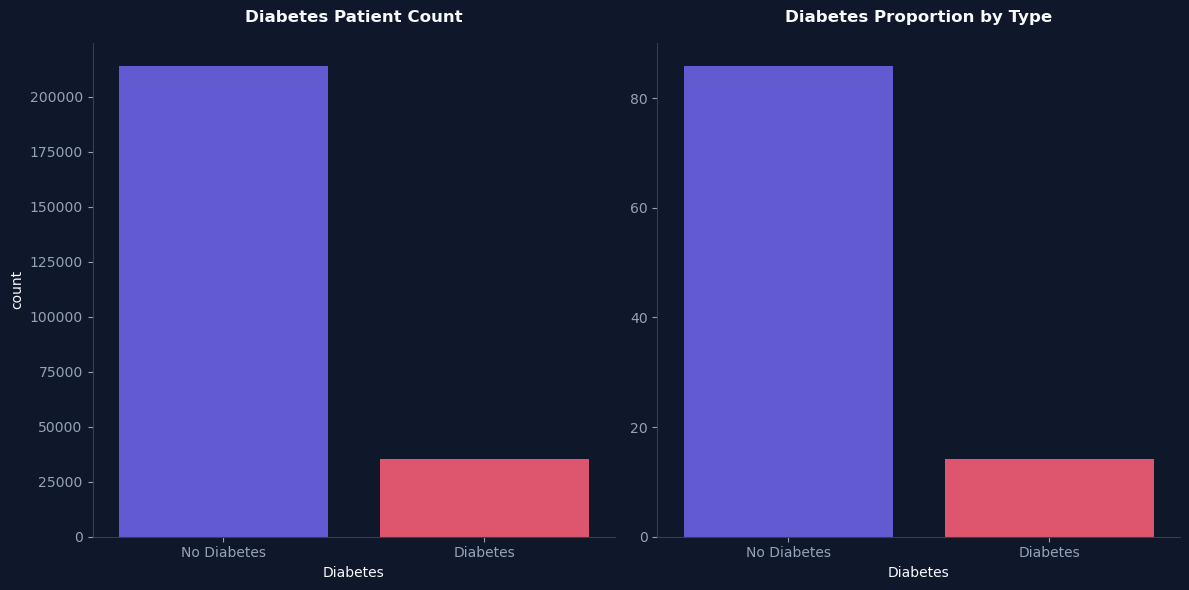

In [84]:
# fig,ax = plt.subplots(1,2,figsize=(10,6))
# sns.countplot(data=df,x="Diabetes",ax=ax[0])
# sns.barplot(x=vc.index,y=vc.values,ax=ax[1])


# --- Premium Seaborn Chart ---
fig,ax = plt.subplots(1,2,figsize=(12,6))
sns.countplot(data=df, x="Diabetes", ax=ax[0], palette=premium_colors)
sns.barplot(x=vc.index, y=vc.values, ax=ax[1], palette=premium_colors)
ax[0].set_title("Diabetes Patient Count", pad=15, fontweight='bold')
ax[1].set_title("Diabetes Proportion by Type", pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Step 6 — Continuous Variable Distribution Analysis

Three features in this dataset have meaningful continuous distributions:

| Feature | Description | Range |
|---------|-------------|-------|
| **`BMI`** | Body Mass Index | 12 – 98 |
| **`MentHlth`** | Poor mental health days (last 30) | 0 – 30 |
| **`PhysHlth`** | Poor physical health days (last 30) | 0 – 30 |

For each variable we plot:
- **Histogram + KDE curve** — reveals the shape and modality of the distribution
- **Boxplot** — shows the median, IQR, and spread of the data

> **Observation:** Both `MentHlth` and `PhysHlth` are heavily **zero-inflated** (most people report 0 bad days), creating a highly skewed distribution. `BMI` is approximately normal but with a long right tail.


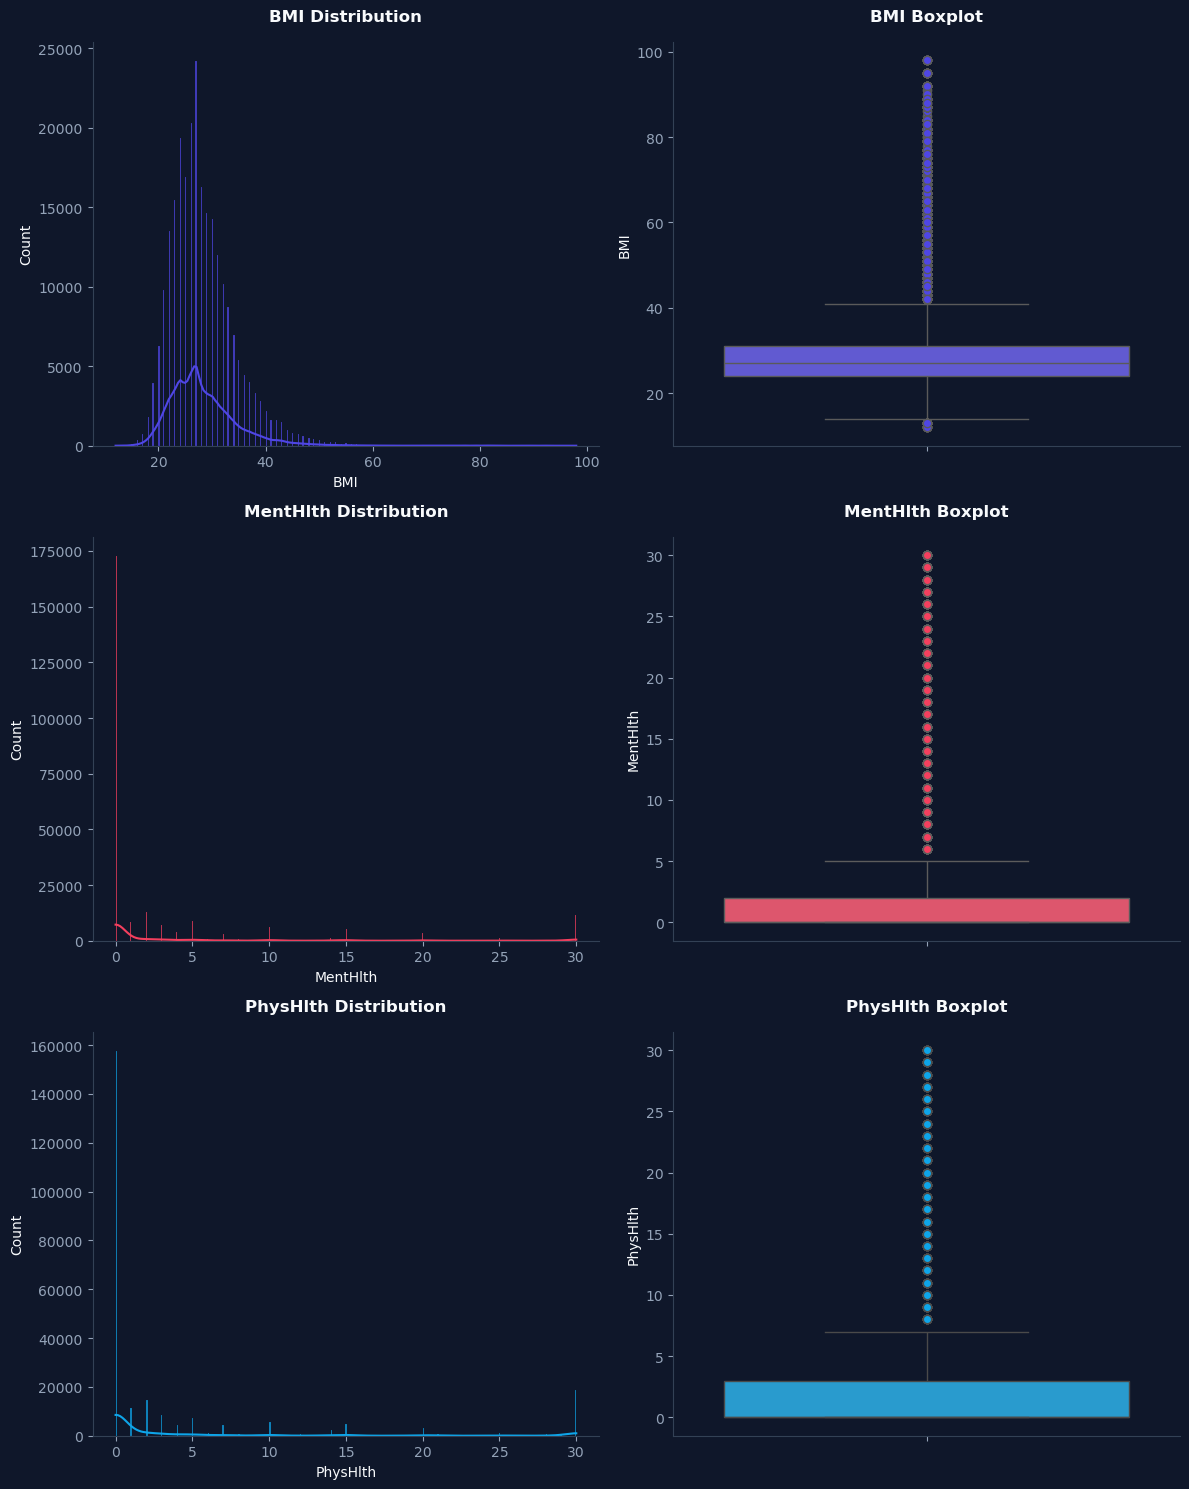

In [85]:
# num = ["BMI","MentHlth","PhysHlth"]
# 
# fig,ax = plt.subplots(3,2,figsize=(10,15))
# for i,col in enumerate(num):
#     sns.histplot(data=df, x=col,kde=True, ax=ax[i,0])
#     sns.boxplot(data=df, y=col, ax=ax[i,1])


# --- Premium Seaborn Chart ---
num = ["BMI","MentHlth","PhysHlth"]
fig,ax = plt.subplots(3,2,figsize=(12,15))
for i,col in enumerate(num):
    sns.histplot(data=df, x=col, kde=True, ax=ax[i,0], color=premium_colors[i], edgecolor="#0f172a", alpha=0.8)
    sns.boxplot(data=df, y=col, ax=ax[i,1], color=premium_colors[i], flierprops={"marker": "o", "markerfacecolor": premium_colors[i]})
    ax[i,0].set_title(f"{col} Distribution", pad=15, fontweight='bold')
    ax[i,1].set_title(f"{col} Boxplot", pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Step 7 — Categorical & Binary Feature Distributions

We visualize the count distributions of all binary and categorical features in the dataset. This helps us understand:

- **Population prevalence** of each health risk factor
- Whether any features are extremely skewed (near-zero variance)
- Which lifestyle and demographic groups are most represented

> Features like `HvyAlcoholConsump` and `Stroke` are strongly right-skewed (rare events), while `Fruits` and `Veggies` have a more balanced split.


C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1872049906.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1872049906.py:25: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(x=df[col], order=order, palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1872049906.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=order, palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1872049906.py:25: UserWarning: The palette list has more values (9) than needed (2), which may

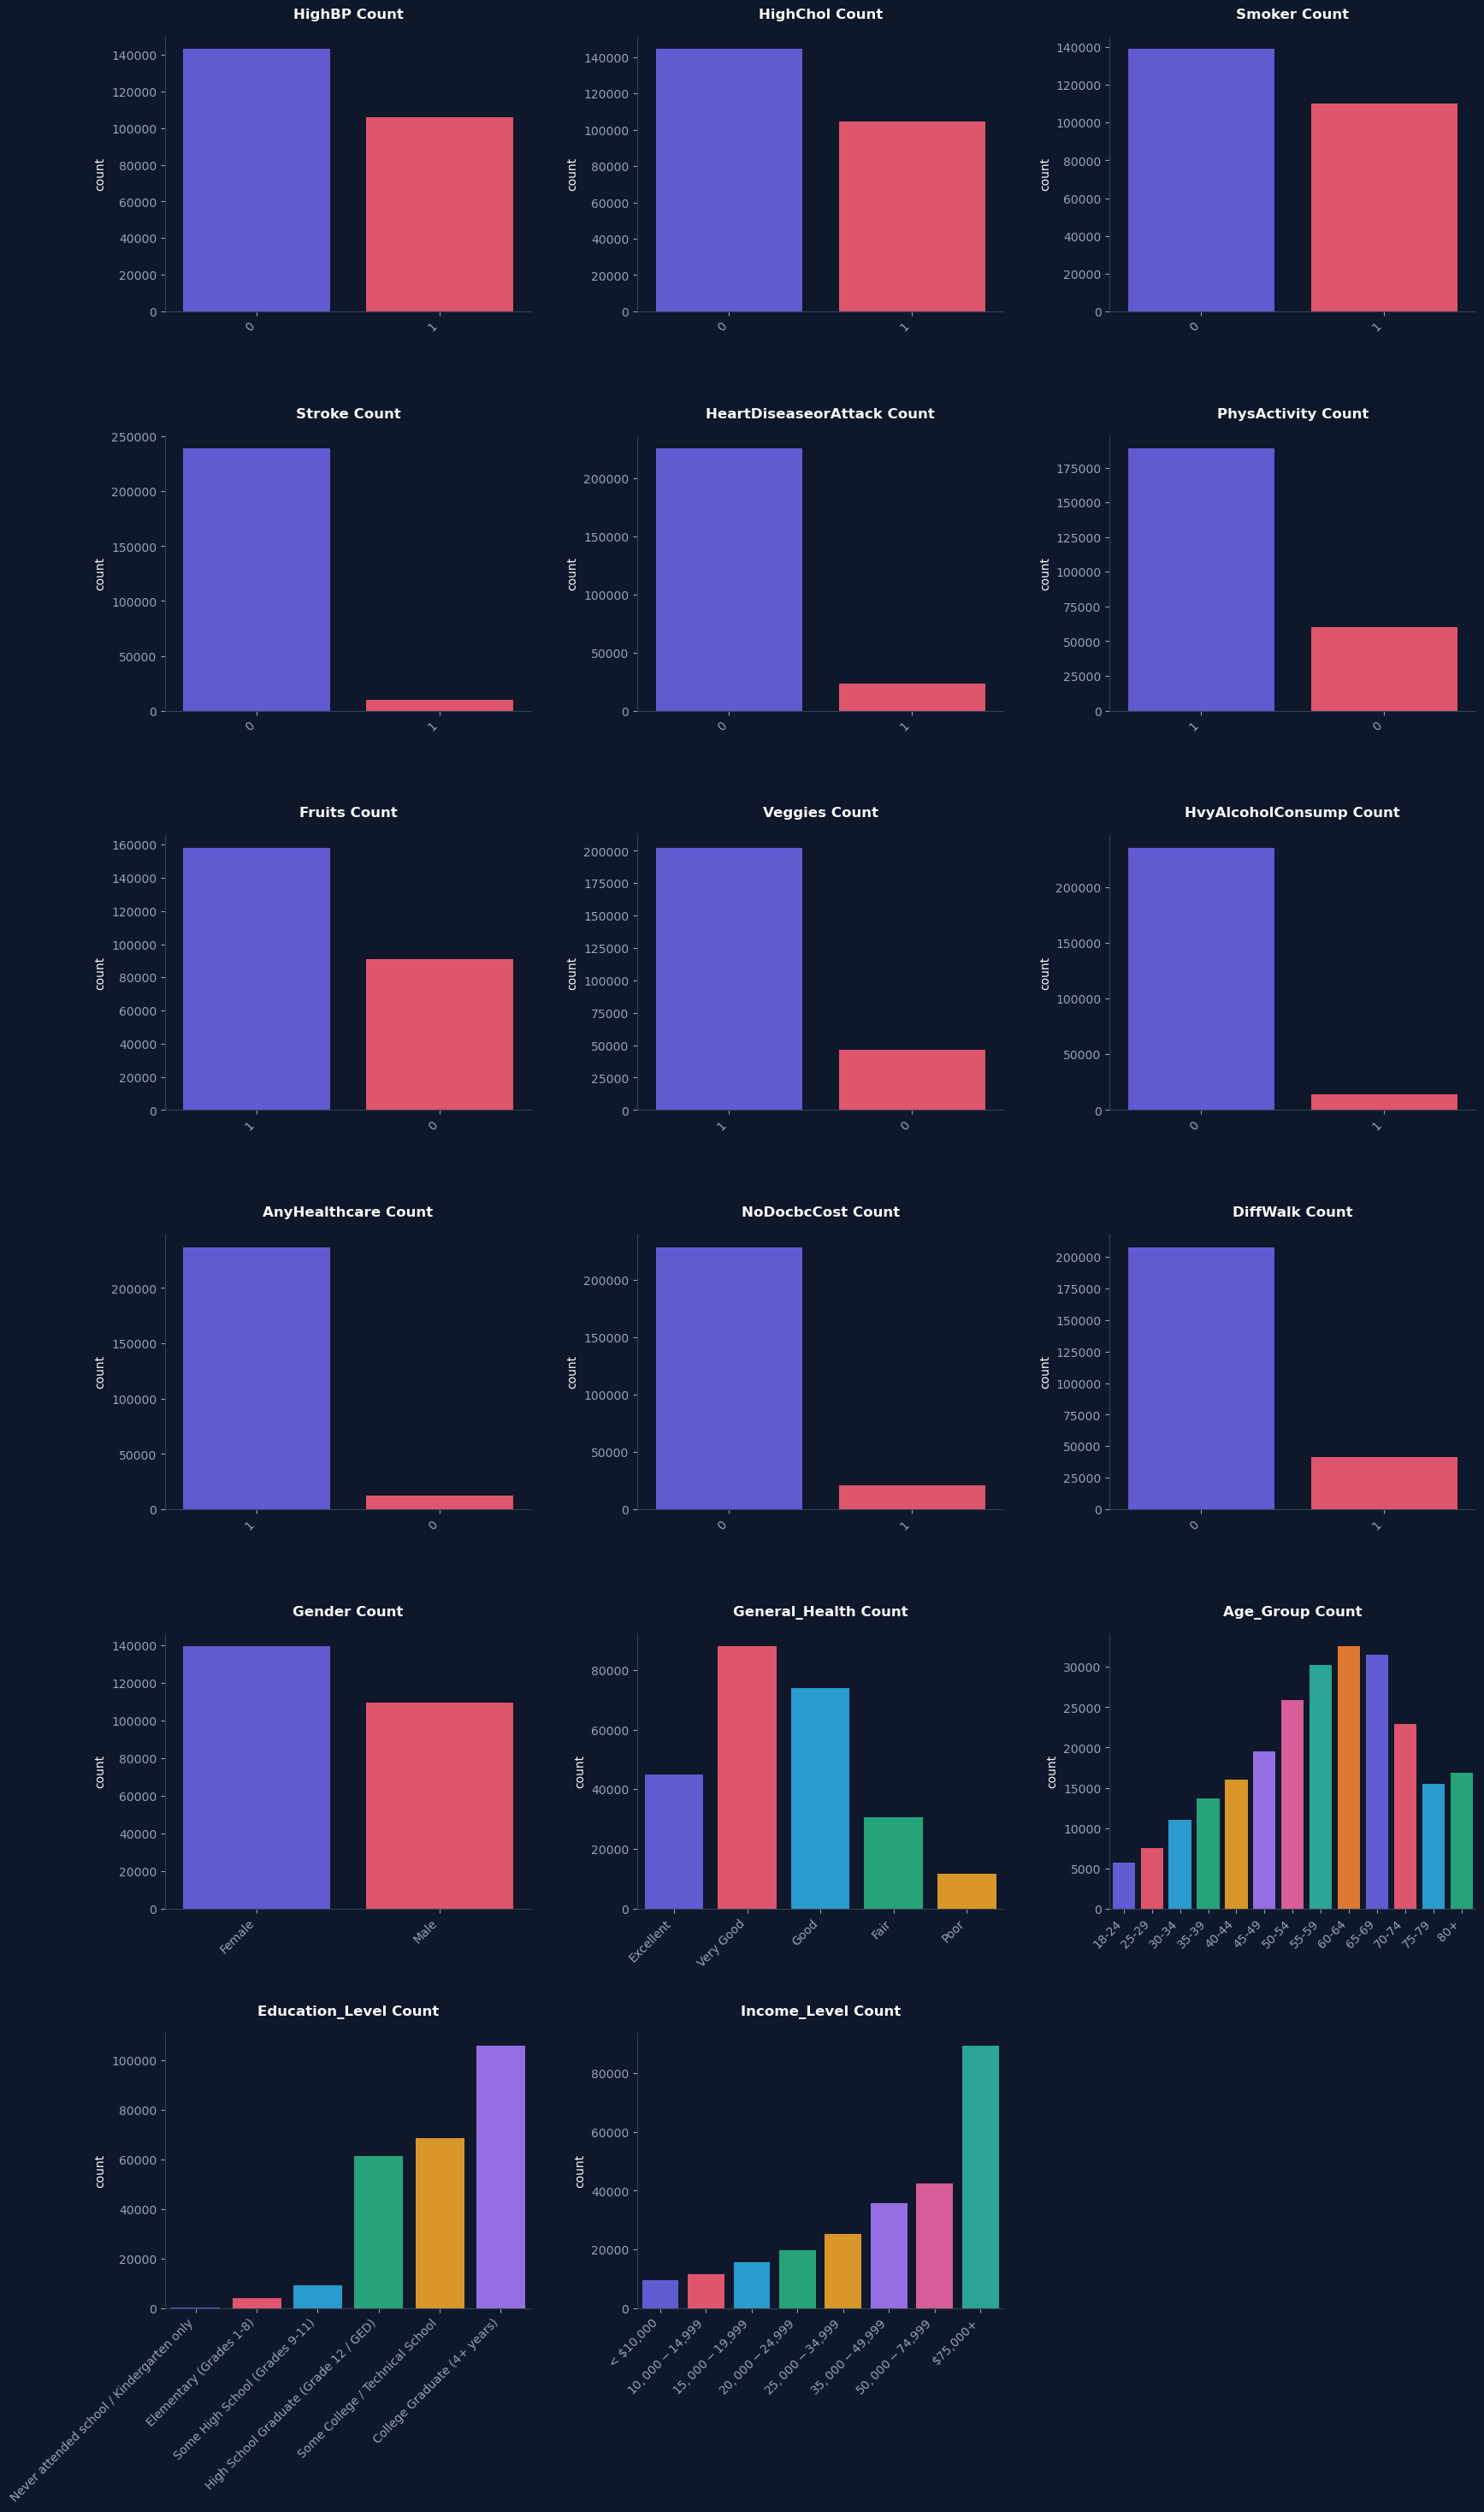

In [86]:
# categorical = ["HighBP","HighChol","Smoker",'Stroke','HeartDiseaseorAttack','PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Gender','General_Health','Age_Group','Education_Level','Income_Level']
# 
# plt.figure(figsize=(15,20))
# for i,col in enumerate(categorical,1):
#     plt.subplot(6,3,i)
#     sns.countplot(x=df[col])
#     plt.xticks(rotation=90)



# --- Premium Seaborn Chart ---
categorical = ["HighBP","HighChol","Smoker",'Stroke','HeartDiseaseorAttack','PhysActivity','Fruits','Veggies','HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Gender','General_Health','Age_Group','Education_Level','Income_Level']

category_orders = {
    "General_Health": ["Excellent", "Very Good", "Good", "Fair", "Poor"],
    "Age_Group": ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80+"],
    "Education_Level": ["Never attended school / Kindergarten only", "Elementary (Grades 1-8)", "Some High School (Grades 9-11)", "High School Graduate (Grade 12 / GED)", "Some College / Technical School", "College Graduate (4+ years)"],
    "Income_Level": ["< $10,000", "$10,000 - $14,999", "$15,000 - $19,999", "$20,000 - $24,999", "$25,000 - $34,999", "$35,000 - $49,999", "$50,000 - $74,999", "$75,000+"]
}

plt.figure(figsize=(18,30))
for i,col in enumerate(categorical,1):
    plt.subplot(6,3,i)
    order = category_orders.get(col, df[col].value_counts().index)
    sns.countplot(x=df[col], order=order, palette=premium_colors)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{col} Count", pad=15, fontweight='bold')
    plt.xlabel("")
plt.tight_layout(pad=3.0)
plt.show()

## 🔬 Step 8 — Bivariate Analysis: BMI vs. Diabetes Status

We examine how **BMI** relates to diabetes status using:
- **Boxplot** — compares median BMI and spread across both classes
- **KDE (Kernel Density Estimate) plot** — shows the full distribution shape of BMI for each class

> **Expected finding:** Diabetic patients should show a notably higher median BMI, consistent with clinical literature linking obesity to Type 2 Diabetes.


C:\Users\saika\AppData\Local\Temp\ipykernel_24248\754548303.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Diabetes"], y=df["BMI"], ax=ax[0], palette=premium_colors)
C:\Users\saika\AppData\Local\Temp\ipykernel_24248\754548303.py:18: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.boxplot(x=df["Diabetes"], y=df["BMI"], ax=ax[0], palette=premium_colors)


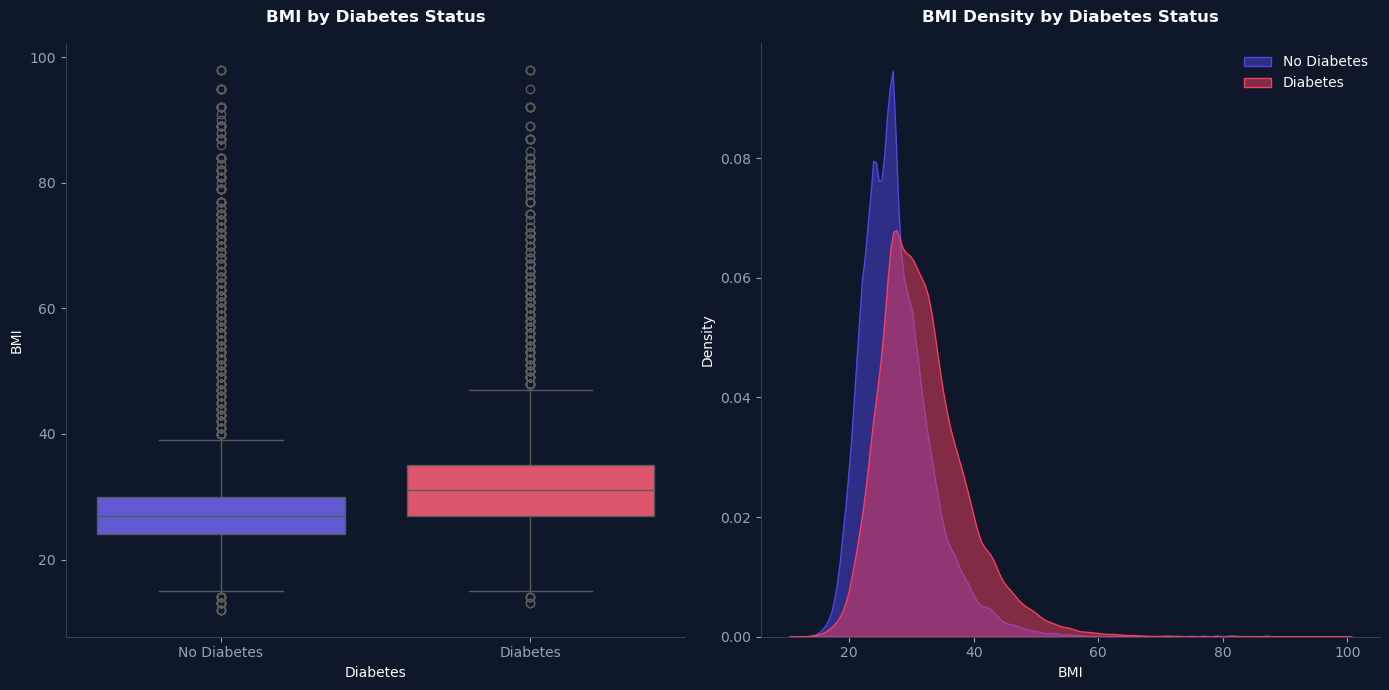

In [87]:
# fig, ax = plt.subplots(1, 2, figsize=(10,8))
# sns.boxplot(x=df["Diabetes"], y=df["BMI"], ax=ax[0])
# for cls in df["Diabetes"].unique():
#     sns.kdeplot(
#         data=df[df["Diabetes"] == cls],
#         x="BMI",
#         fill=True,
#         alpha=0.3,
#         label=cls,
#         ax=ax[1]
#     )
# plt.show()
# 


# --- Premium Seaborn Chart ---
fig, ax = plt.subplots(1, 2, figsize=(14,7))
sns.boxplot(x=df["Diabetes"], y=df["BMI"], ax=ax[0], palette=premium_colors)
ax[0].set_title("BMI by Diabetes Status", pad=15, fontweight='bold')

for i, cls in enumerate(df["Diabetes"].unique()):
    sns.kdeplot(
        data=df[df["Diabetes"] == cls],
        x="BMI",
        fill=True,
        alpha=0.5,
        label=cls,
        ax=ax[1],
        color=premium_colors[i]
    )
ax[1].set_title("BMI Density by Diabetes Status", pad=15, fontweight='bold')
ax[1].legend(frameon=False)
plt.tight_layout()
plt.show()

## 🔬 Step 9 — Risk Factor Profiling by Diabetes Status

For each categorical and binary risk factor, we compare how its distribution differs between diabetic and non-diabetic populations. This reveals which features are the **strongest discriminating signals** for our classification task.

> **Key patterns to watch for:**
> - `HighBP`: Diabetic patients are expected to show much higher rates of high blood pressure
> - `General_Health`: Diabetic patients are expected to cluster in the "Fair" and "Poor" health categories
> - `Age_Group`: Prevalence of diabetes should rise steeply with age


C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


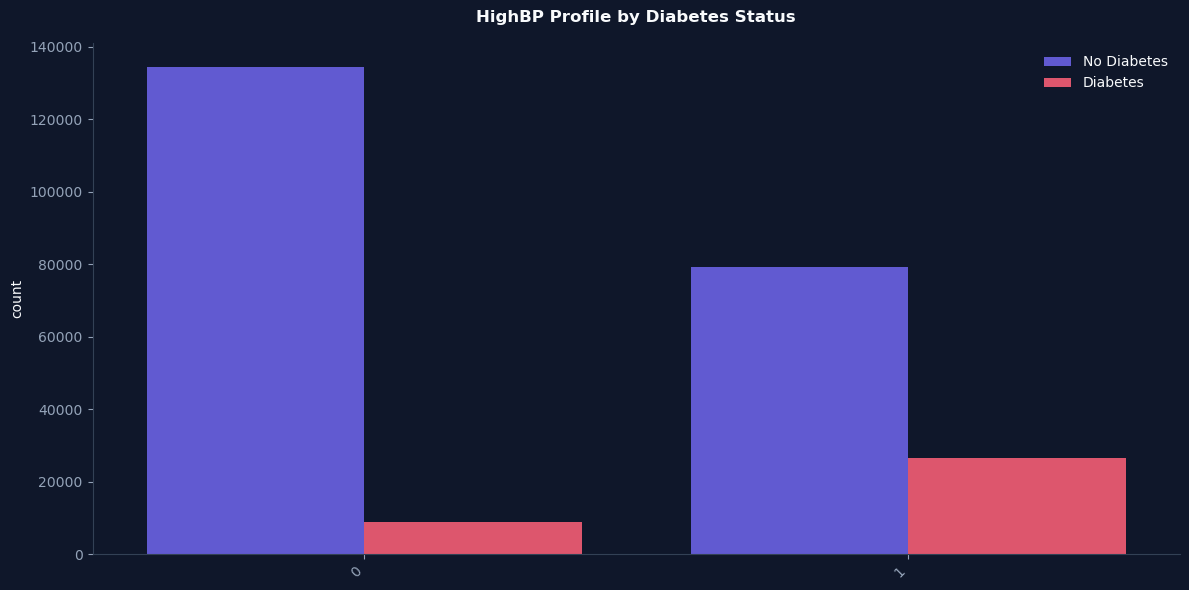

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


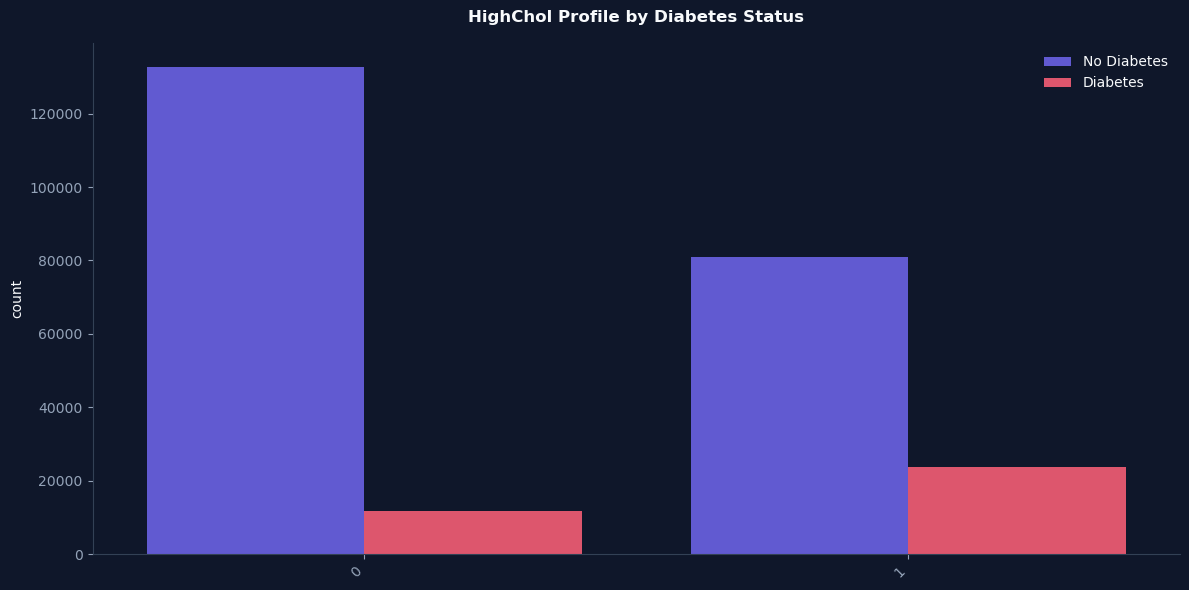

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


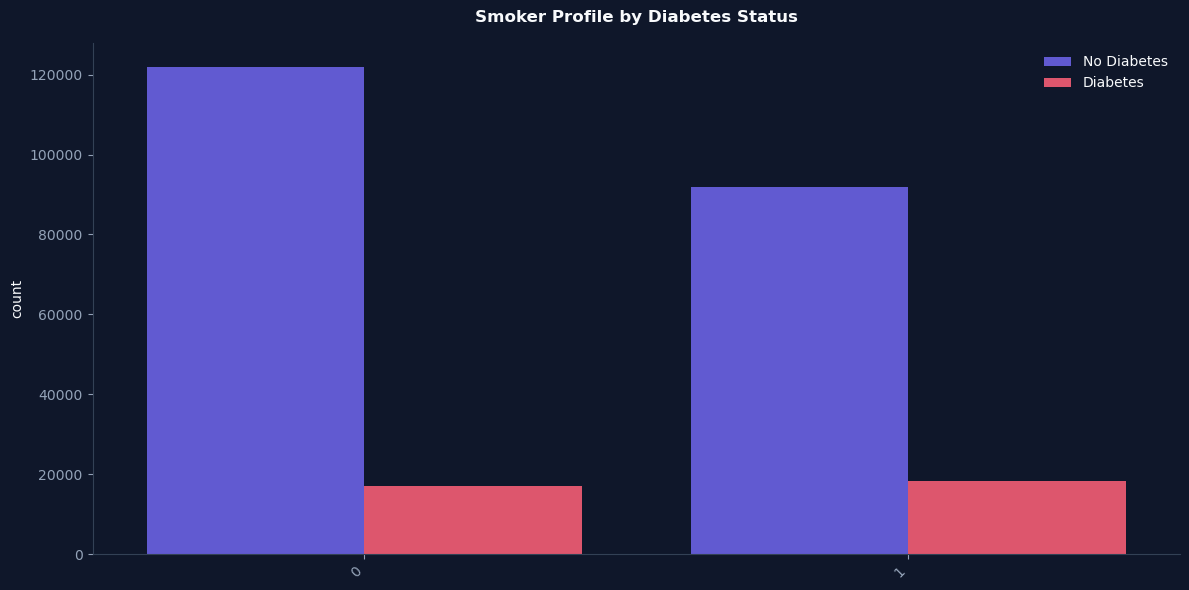

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


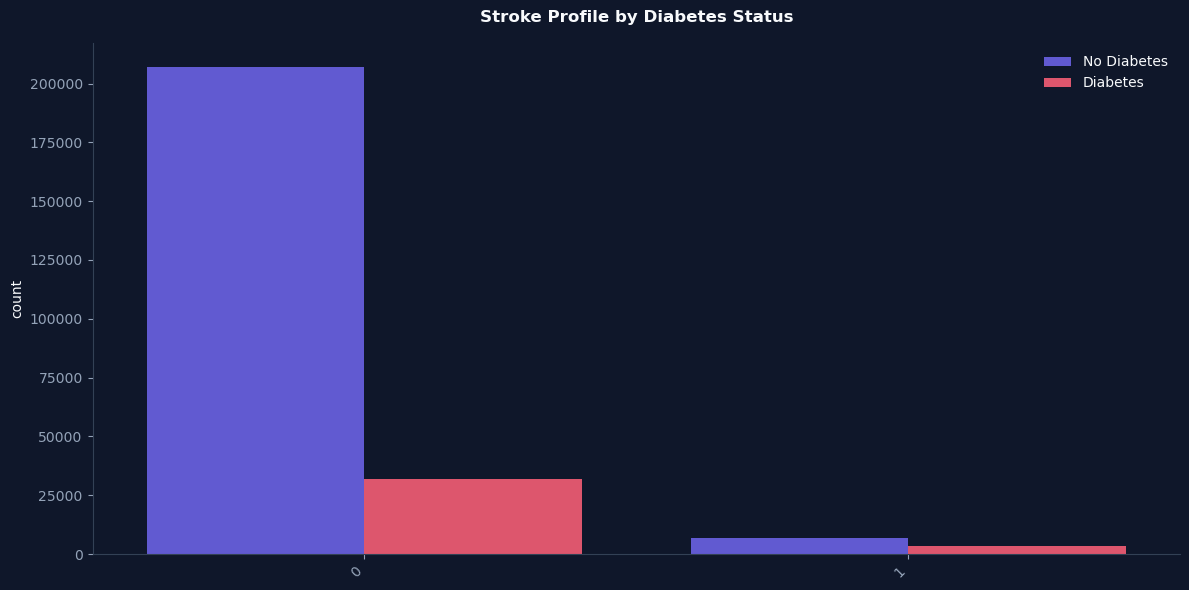

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


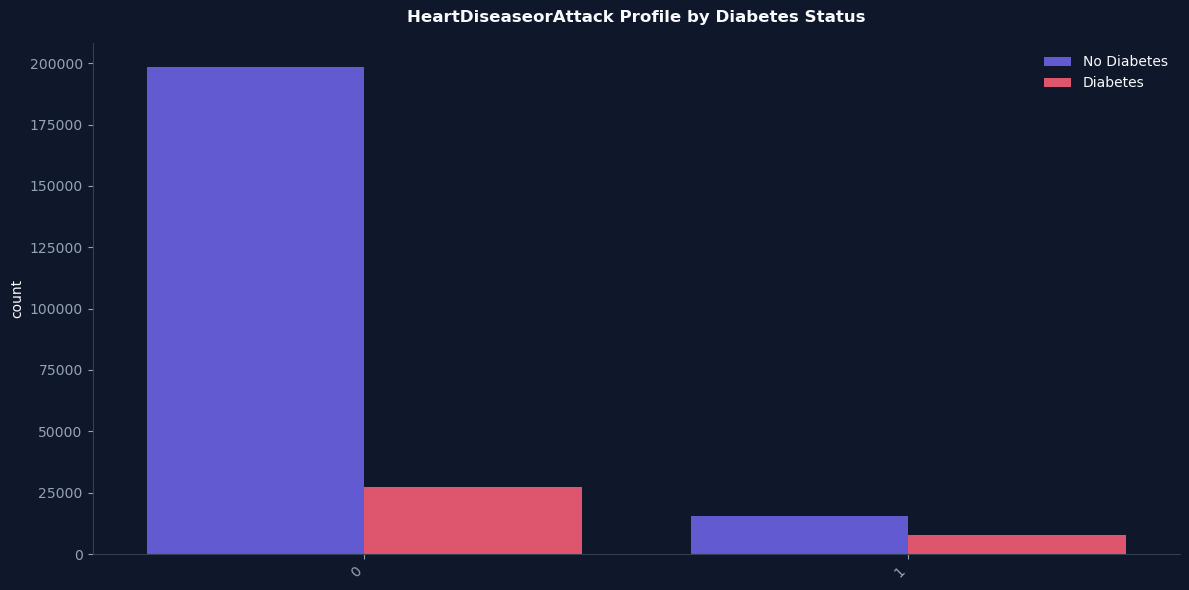

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


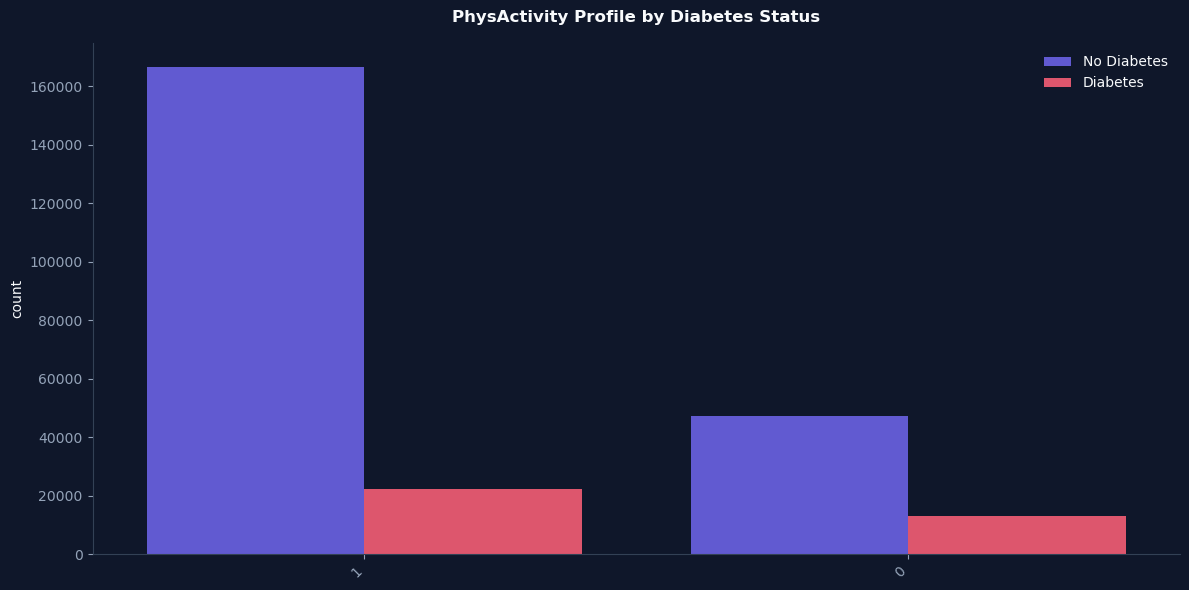

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


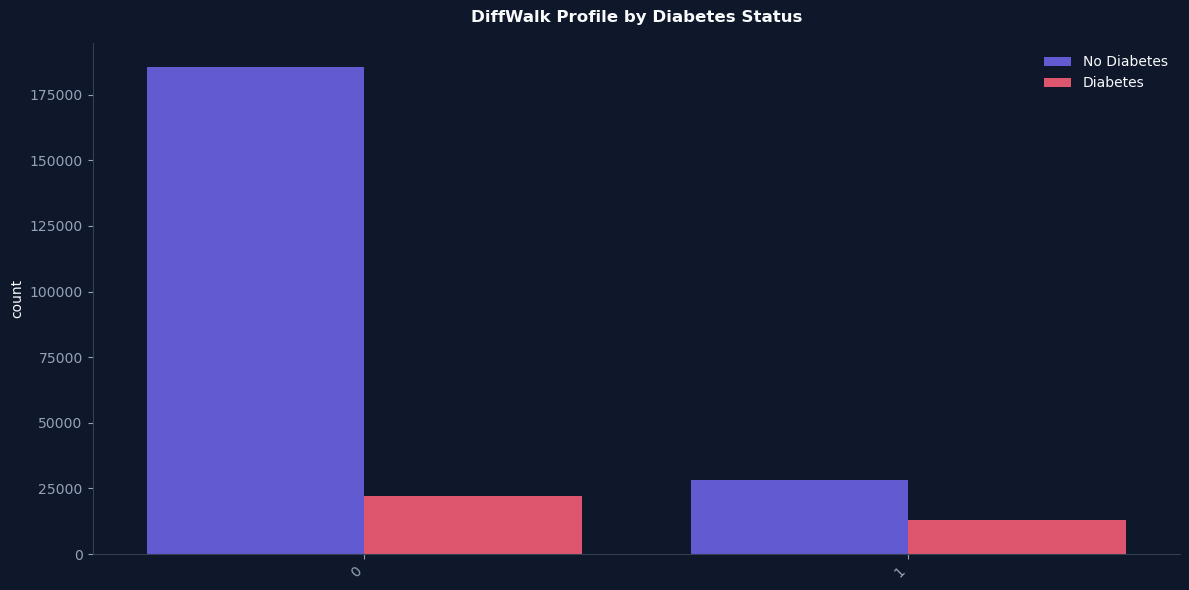

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


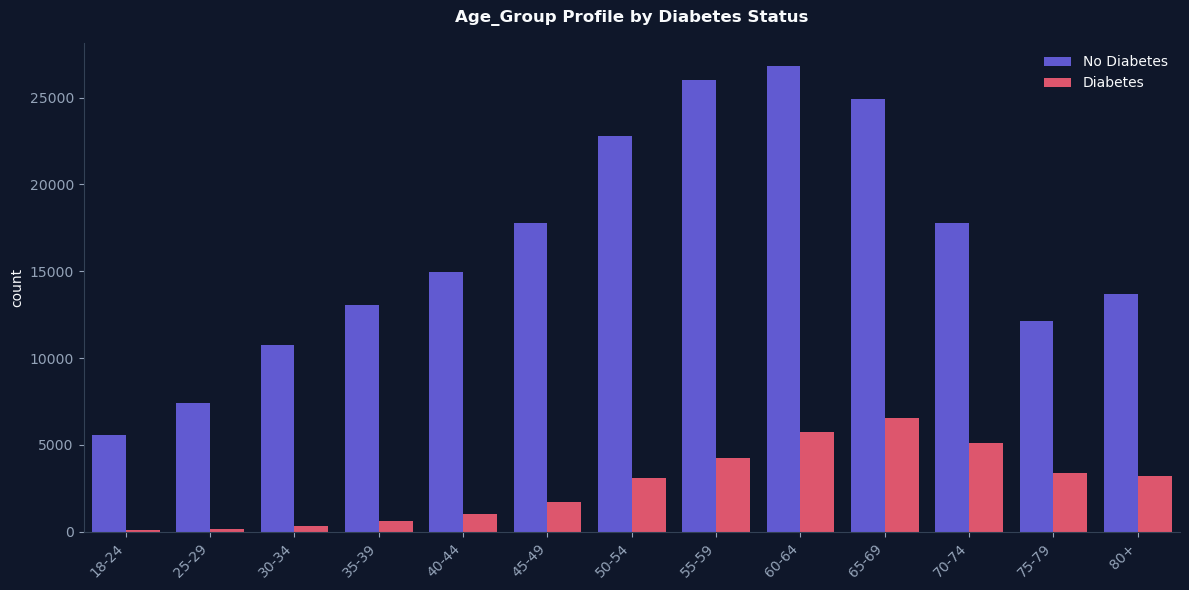

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


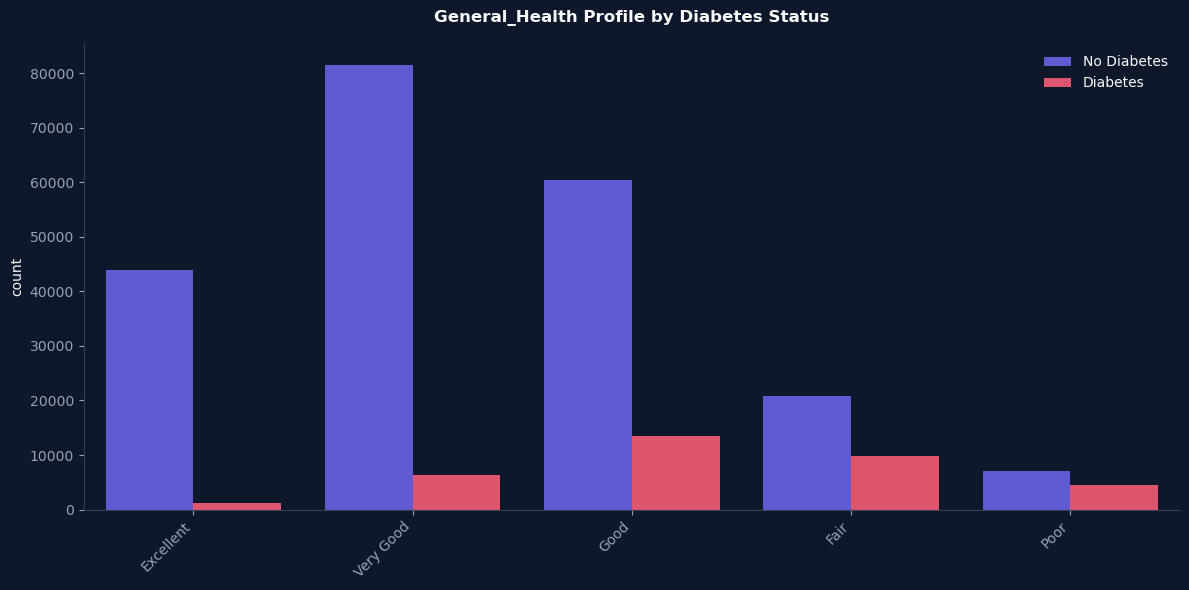

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


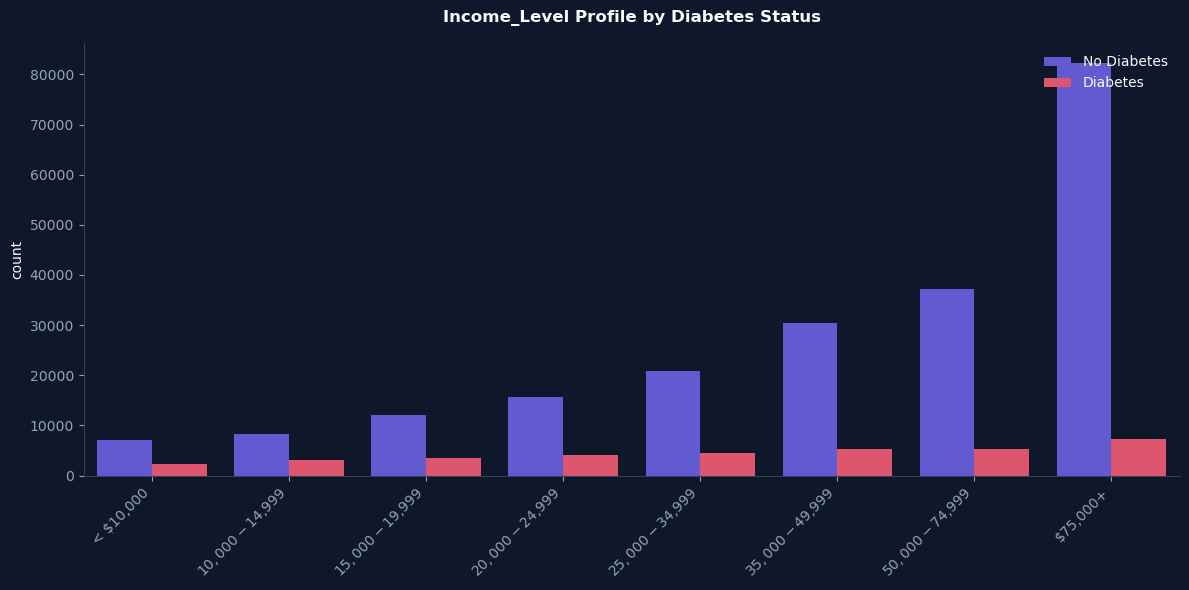

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


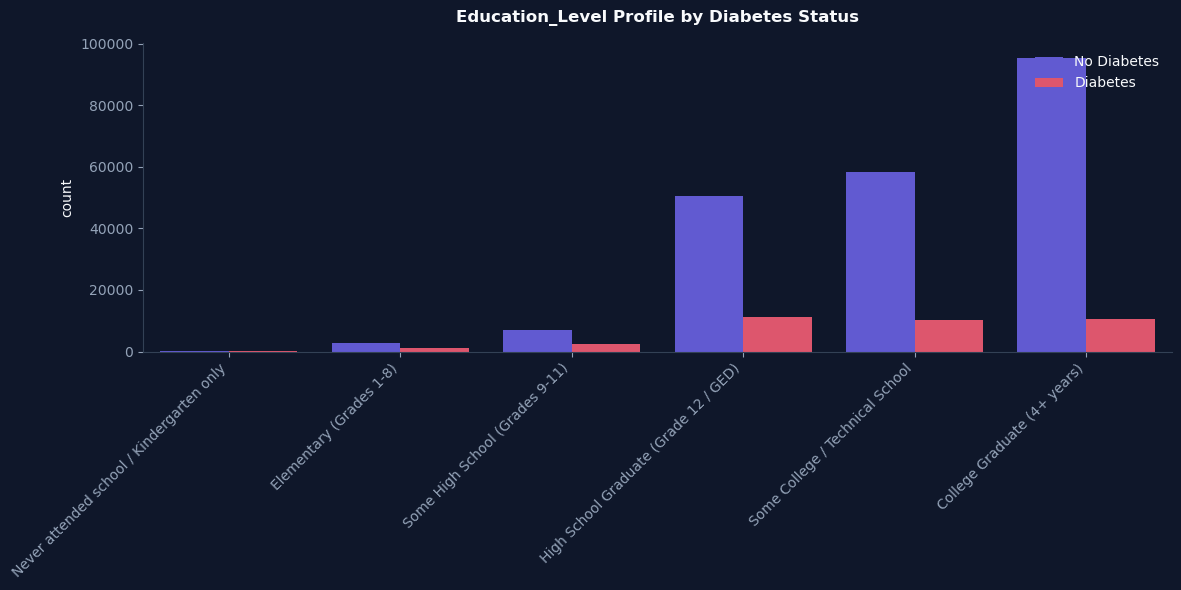

C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1456774897.py:42: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)


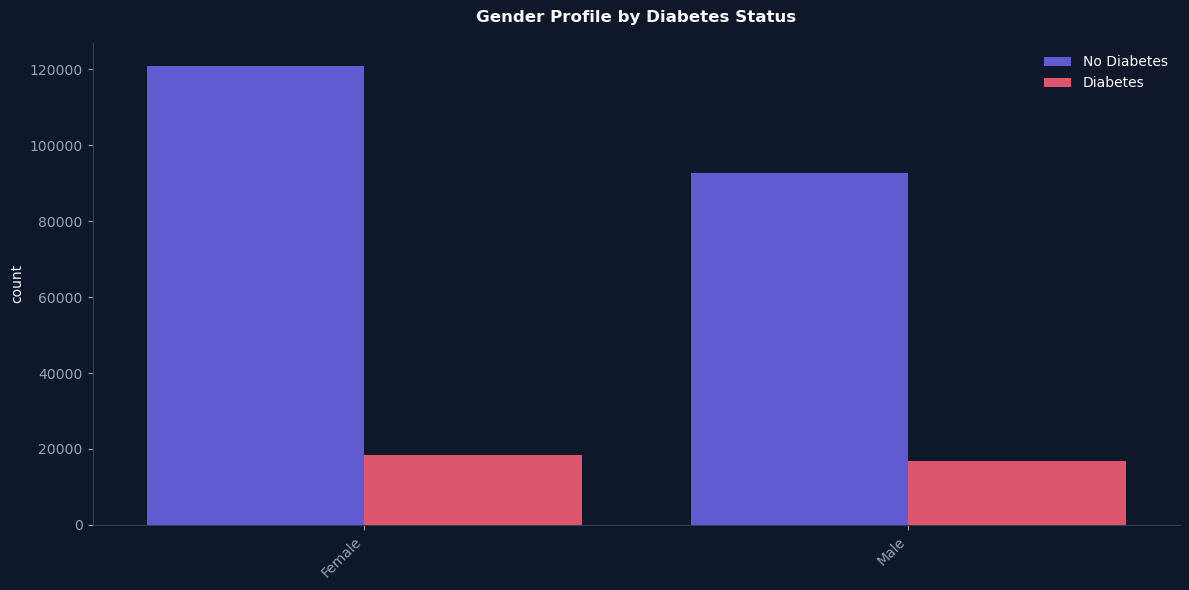

In [88]:
# categorical = [
#     "HighBP",
#     "HighChol",
#     "Smoker",
#     "Stroke",
#     "HeartDiseaseorAttack",
#     "PhysActivity",
#     "DiffWalk",
#     "Age_Group",
#     "General_Health",
#     "Income_Level",
#     "Education_Level",
#     "Gender"
# ]
# 
# for col in categorical:
#     plt.figure(figsize=(6,4))
#     sns.countplot(data=df, x=col, hue="Diabetes")
#     plt.xticks(rotation=90)
#     plt.title(f"{col} vs Diabetes")
#     plt.show()



# --- Premium Seaborn Chart ---
categorical = [
    "HighBP", "HighChol", "Smoker", "Stroke", "HeartDiseaseorAttack", 
    "PhysActivity", "DiffWalk", "Age_Group", "General_Health", 
    "Income_Level", "Education_Level", "Gender"
]

category_orders = {
    "General_Health": ["Excellent", "Very Good", "Good", "Fair", "Poor"],
    "Age_Group": ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80+"],
    "Education_Level": ["Never attended school / Kindergarten only", "Elementary (Grades 1-8)", "Some High School (Grades 9-11)", "High School Graduate (Grade 12 / GED)", "Some College / Technical School", "College Graduate (4+ years)"],
    "Income_Level": ["< $10,000", "$10,000 - $14,999", "$15,000 - $19,999", "$20,000 - $24,999", "$25,000 - $34,999", "$35,000 - $49,999", "$50,000 - $74,999", "$75,000+"]
}

for col in categorical:
    plt.figure(figsize=(12,6))
    order = category_orders.get(col, df[col].value_counts().index)
    sns.countplot(data=df, x=col, hue="Diabetes", order=order, palette=premium_colors)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"{col} Profile by Diabetes Status", pad=15, fontweight='bold')
    plt.xlabel("")
    plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

## 🌡️ Step 10 — Feature Correlation Heatmap

The **Pearson Correlation Matrix** visualizes pairwise linear relationships between all numeric features.

> **What to look for:**
> - **High positive correlation (red):** Features that tend to increase together
> - **High negative correlation (blue):** Features with an inverse relationship
> - **Near-zero correlation (white):** Approximately independent features
>
> Strong inter-feature correlations can indicate **multicollinearity**, which we will formally test using VIF in the next step.


<Axes: >

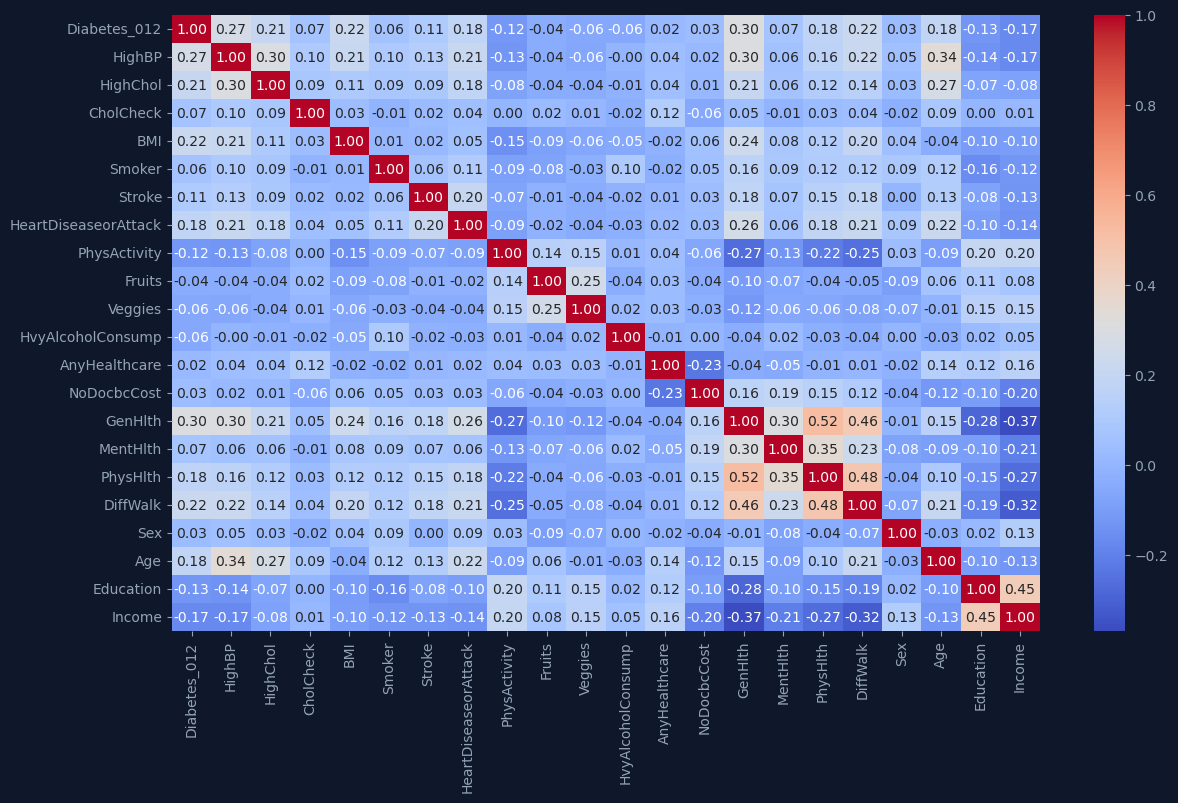

In [89]:
plt.figure(figsize=(14,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

## 🔎 Step 11 — Outlier Detection via IQR Method

We calculate the number of statistical outliers in each column using the **Interquartile Range (IQR)** method:

$$\text{IQR} = Q3 - Q1$$
$$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$

Any value outside these bounds is flagged as an "outlier."


In [90]:
numeric = df.select_dtypes(include="int").columns

Q1 = df[numeric].quantile(0.25)
Q3 = df[numeric].quantile(0.75)
IQR = Q3-Q1
outliers = ((df[numeric]<(Q1-1.5*IQR))|(df[numeric]>(Q3+1.5*IQR))).sum()
print(outliers)

Diabetes_012            35346
HighBP                      0
HighChol                    0
CholCheck                9408
BMI                      9556
Smoker                      0
Stroke                  10027
HeartDiseaseorAttack    23229
PhysActivity            60271
Fruits                      0
Veggies                 46769
HvyAlcoholConsump       14048
AnyHealthcare           12163
NoDocbcCost             20755
GenHlth                 11730
MentHlth                35273
PhysHlth                39778
DiffWalk                41390
Sex                         0
Age                         0
Education                   0
Income                      0
dtype: int64


### ⚠️ Why We Do NOT Drop These Outliers

The IQR-based outlier counts appear alarmingly large. However, **dropping these rows would be scientifically and statistically incorrect** for this dataset. Here is why:

---

#### 1. IQR Is Invalid on Binary Features

For binary columns like `Stroke`, `HeartDiseaseorAttack`, or `Veggies`:
- If more than 75% of patients have `0` (e.g., no stroke), then $Q1 = Q3 = 0$, making $\text{IQR} = 0$
- This means the upper bound is **also 0** — so every patient with value `1` (who had a stroke) gets flagged as an outlier
- **Dropping these rows deletes our most medically relevant patients**

#### 2. Extreme Clinical Values Are Meaningful

For continuous features like `BMI`:
- A BMI > 41.5 is classified as **severe obesity** — a well-established clinical risk factor for diabetes
- In this dataset, the diabetic rate in the BMI > 41.5 group is **~35%** (vs. the overall rate of ~14.2%) — **2.5× higher than baseline**
- Dropping them removes over **3,300 confirmed Diabetes cases**, severely biasing the model toward healthy patients

#### 3. Chronic Illness Days Are Not Noise

For `PhysHlth` and `MentHlth`:
- Reporting 8–30 bad health days per month indicates a **chronic condition**, not a data entry error
- These patients are precisely the at-risk population our model needs to learn from

---

### ✅ Decision: Retain All Rows

- **Tree-based models** (Decision Tree, Random Forest, XGBoost, Gradient Boosting) are inherently **robust to outliers** — no deletion needed
- **Scale-sensitive models** (Logistic Regression, KNN, SVM) will use `StandardScaler` in their pipelines, which mitigates the effect of extreme values through normalization

---

## 🔗 Step 12 — Multicollinearity Check: Variance Inflation Factor (VIF)

**VIF** measures how much the variance of a regression coefficient is inflated due to multicollinearity with other features.

| VIF Value | Interpretation |
|-----------|----------------|
| 1 | No multicollinearity |
| 1 – 5 | Low to moderate — acceptable |
| 5 – 10 | Moderate — warrants investigation |
| > 10 | High — strong multicollinearity present |

> We use this to identify redundant features that could destabilize coefficient-based models like Logistic Regression.


In [91]:
X = df.select_dtypes(include="number").drop(columns=["Diabetes_012"])

X = add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                 Feature         VIF
0                  const  115.799238
1                 HighBP    1.330805
2               HighChol    1.173099
3              CholCheck    1.032856
4                    BMI    1.139074
5                 Smoker    1.091999
6                 Stroke    1.081668
7   HeartDiseaseorAttack    1.172636
8           PhysActivity    1.158009
9                 Fruits    1.112515
10               Veggies    1.112351
11     HvyAlcoholConsump    1.024134
12         AnyHealthcare    1.112468
13           NoDocbcCost    1.141733
14               GenHlth    1.793477
15              MentHlth    1.236539
16              PhysHlth    1.622043
17              DiffWalk    1.534124
18                   Sex    1.075065
19                   Age    1.349995
20             Education    1.325498
21                Income    1.502023


## ⚙️ Step 13 — Model Preprocessing Pipeline

Before training, we prepare the modeling DataFrame by:

1. **Dropping EDA-only columns** — `Diabetes`, `Gender`, `General_Health`, `Age_Group`, `Education_Level`, and `Income_Level` are label-mapped string columns created for visualization. The model will train on the original integer-coded features only.
2. **Defining features (`x`) and target (`y`)** — `Diabetes_012` is our binary target; all remaining columns are input features.
3. **Stratified Train-Test Split (70/30)** — We use `stratify=y` to preserve the class ratio in both training and test sets.
4. **SMOTE Oversampling** — Applied *only* to the **training set** to address class imbalance by synthetically generating new minority-class (Diabetes) samples. The test set remains untouched to preserve an honest evaluation.

> ⚠️ SMOTE is applied **after** the train-test split to prevent data leakage. The test set reflects the true population distribution.


In [92]:
eda_columns = [
    "Diabetes",
    "Gender",
    "General_Health",
    "Age_Group",
    "Education_Level",
    "Income_Level"
]

df_model = df.drop(columns=eda_columns)

x = df_model.drop("Diabetes_012",axis=1)
y = df_model["Diabetes_012"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,stratify=y,random_state=42)

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train,y_train)

## 🛠️ Step 14 — Helper Functions: `tune()` and `evaluate()`

We define two reusable utility functions that are used across all model training cells:

### `tune(clf, param_grid, x_train, y_train)`
Performs **GridSearchCV with Stratified K-Fold Cross-Validation** to find the optimal hyperparameters for a given classifier. Uses `recall` as the scoring metric — ensuring we optimize for catching as many diabetic cases as possible.

### `evaluate(model, x_test, y_test, model_name)`
Computes a comprehensive set of classification metrics on the test set and returns a formatted DataFrame:
- Per-class precision, recall, and F1-score (for both class 0 and class 1)
- Macro-averaged metrics
- Overall accuracy

### `evaluate_train(model, x_train, y_train, model_name)`
Same as `evaluate()` but computed on the training set — used for overfitting detection by comparing train vs. test performance.


In [100]:
def tune(clf, param_grid, x_train, y_train, scoring='recall', n_splits=3):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(x_train,y_train)
    best_hyperparamters = grid.best_params_
    return grid.best_estimator_ , best_hyperparamters

def evaluate(model,x_test,y_test,model_name):
    y_pred = model.predict(x_test)
    report = classification_report(y_test,y_pred, output_dict=True)
    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred)
    }

    evaluation = pd.DataFrame(metrics, index=[model_name]).round(2)
    return evaluation

def evaluate_train(model,x_train,y_train,model_name):
    y_pred = model.predict(x_train)
    report = classification_report(y_train,y_pred, output_dict=True)
    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_train, y_pred)
    }

    evaluation = pd.DataFrame(metrics, index=[model_name]).round(2)
    return evaluation

---

## 🌳 Model 1 — Decision Tree Classifier

**Decision Trees** are interpretable, non-parametric models that partition the feature space using a series of binary splits. Each node asks a yes/no question about a feature value, and predictions are made by traversing from root to leaf.

**Strengths:** Highly interpretable, handles non-linearity, no feature scaling required
**Weaknesses:** Prone to overfitting without depth constraints

**Key Hyperparameters Tuned:**
- `criterion`: Split quality measure (Gini impurity vs. Entropy)
- `max_depth`: Maximum tree depth (controls overfitting)
- `min_samples_split` / `min_samples_leaf`: Minimum samples required to split/form a leaf (regularization)
- `max_features`: Features considered at each split

> `class_weight="balanced"` adjusts for the class imbalance in the SMOTE-resampled training data.


In [ ]:
dt = DecisionTreeClassifier(random_state=42,class_weight="balanced")
param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", "log2", None]
}

if os.path.exists("best_model_dt.pkl"):
    print("Loading saved Decision Tree...")
    best_model_dt = joblib.load("best_model_dt.pkl")
    best_para_dt = {}
else:
    print("Training Decision Tree...")
    best_model_dt, best_para_dt = tune(dt,param_grid_dt,x_train_smote,y_train_smote)
    joblib.dump(best_model_dt, "best_model_dt.pkl")
    
dt_evaluation = evaluate(best_model_dt,x_test,y_test,'DT_Test')
dt_evaluation_train = evaluate_train(best_model_dt,x_train_smote,y_train_smote,'DT_Train')
both = [dt_evaluation, dt_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT_Test,0.96,0.25,0.59,0.84,0.73,0.39,0.61,0.72,0.56,0.63
DT_Train,0.76,0.66,0.59,0.81,0.66,0.73,0.71,0.70,0.70,0.70


---

## 🌲 Model 2 — Random Forest Classifier

**Random Forest** is a bagging ensemble of Decision Trees. Each tree is trained on a random bootstrap sample of the data using a random subset of features at each split. The final prediction is made by majority vote across all trees.

**Strengths:** Excellent generalization, robust to overfitting, built-in feature importance
**Weaknesses:** Computationally expensive, less interpretable than single trees

**Key Hyperparameters Tuned:**
- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth per tree
- `max_features`: Features considered at each split (`sqrt` or `log2`)
- `min_samples_split` / `min_samples_leaf`: Leaf size constraints


In [ ]:
rf = RandomForestClassifier(random_state=42,class_weight="balanced")
param_grid_rf = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

if os.path.exists("best_model_rf.pkl"):
    print("Loading saved Random Forest...")
    best_model_rf = joblib.load("best_model_rf.pkl")
    best_para_rf = {}
else:
    print("Training Random Forest...")
    best_model_rf, best_para_rf = tune(rf,param_grid_rf,x_train_smote,y_train_smote)
    
rf_evaluation = evaluate(best_model_rf,x_test,y_test,'RF_Test')
rf_evaluation_train = evaluate_train(best_model_rf,x_train_smote,y_train_smote,'RF_Train')
both = [rf_evaluation, rf_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
RF_Test,0.95,0.31,0.72,0.75,0.82,0.43,0.63,0.73,0.62,0.72
RF_Train,0.79,0.74,0.72,0.81,0.75,0.77,0.77,0.76,0.76,0.76


In [126]:
print(best_para_rf)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}


---

## 👥 Model 3 — K-Nearest Neighbors (KNN)

**KNN** is a non-parametric, instance-based learning algorithm. It classifies a new sample by finding the `k` closest training examples (by Euclidean or Manhattan distance) and taking a majority vote.

**Strengths:** Simple, no explicit training phase, naturally adapts to complex boundaries
**Weaknesses:** Computationally expensive at prediction time, highly sensitive to feature scale

> A **StandardScaler** is applied inside the pipeline before KNN to ensure all features contribute equally to distance calculations.

**Key Hyperparameters Tuned:**
- `n_neighbors`: Number of neighbors to consider
- `weights`: Uniform (equal vote) vs. distance-weighted (closer neighbors vote more)
- `p`: Distance metric (`p=1` = Manhattan, `p=2` = Euclidean)


In [ ]:
knn_pipeline = Pipeline([
    ('Scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

if os.path.exists("best_model_knn.pkl"):
    print("Loading saved KNN...")
    best_model_knn = joblib.load("best_model_knn.pkl")
    best_para_knn = {}
else:
    print("Training KNN...")
    best_model_knn, best_para_knn = tune(knn_pipeline,param_grid_knn,x_train_smote,y_train_smote)
    
knn_evaluation = evaluate(best_model_knn,x_test,y_test,'KNN_Test')
knn_evaluation_train = evaluate_train(best_model_knn,x_train_smote,y_train_smote,'KNN_Train')
both = [knn_evaluation, knn_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
KNN_Test,0.92,0.27,0.72,0.65,0.81,0.38,0.60,0.68,0.60,0.71
KNN_Train,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99


---

## ⚡ Model 4 — Support Vector Machine (Linear SVM)

**Linear SVM** finds the optimal hyperplane that maximizes the margin between the two classes. `LinearSVC` is an efficient implementation using a linear kernel, suitable for large datasets.

**Strengths:** Effective in high-dimensional spaces, strong theoretical guarantees, memory efficient
**Weaknesses:** Does not produce probability estimates, sensitive to feature scale and regularization parameter `C`

> A **StandardScaler** is applied inside the pipeline — SVMs are very sensitive to feature magnitudes.
> `class_weight="balanced"` adjusts decision boundaries for imbalanced classes.

**Key Hyperparameter Tuned:**
- `C`: Regularization strength. Smaller `C` → wider margin, more misclassifications allowed (underfitting). Larger `C` → tighter margin (overfitting risk).


In [ ]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)) 
])
param_grid_svm = {
    'svm__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10]
}

if os.path.exists("best_model_svm.pkl"):
    print("Loading saved SVM...")
    best_model_svm = joblib.load("best_model_svm.pkl")
    best_para_svm = {}
else:
    print("Training SVM...")
    best_model_svm, best_para_svm = tune(svm_pipeline,param_grid_svm,x_train_smote,y_train_smote)

svm_evaluation = evaluate(best_model_svm, x_test, y_test, 'SVM_Test')
svm_evaluation_train = evaluate_train(best_model_svm,x_train_smote,y_train_smote,'SVM_Train')
both = [svm_evaluation, svm_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM_Test,0.94,0.30,0.73,0.70,0.82,0.42,0.62,0.72,0.62,0.73
SVM_Train,0.75,0.74,0.73,0.76,0.74,0.75,0.74,0.74,0.74,0.74


In [165]:
print(best_para_svm)

{'svm__C': 0.01}


---

## 🚀 Model 5 — Gradient Boosting Classifier

**Gradient Boosting** is a sequential ensemble technique that builds trees one at a time, where each new tree corrects the residual errors of the previous ensemble. It uses gradient descent in function space to minimize a differentiable loss function.

**Strengths:** Often achieves state-of-the-art results, handles mixed feature types, built-in regularization
**Weaknesses:** Slower to train than Random Forest, more sensitive to hyperparameters

**Key Hyperparameters Tuned:**
- `learning_rate`: Shrinkage factor applied to each tree's contribution (lower = slower but more robust)
- `n_estimators`: Number of boosting stages
- `max_depth`: Depth of each individual tree
- `subsample`: Fraction of samples used per tree (stochastic gradient boosting)


In [ ]:
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'learning_rate': [0.05],
    'n_estimators': [150],
    'max_depth': [3],
    'subsample': [1.0]
}

if os.path.exists("best_model_gb.pkl"):
    print("Loading saved Gradient Boosting...")
    best_model_gb = joblib.load("best_model_gb.pkl")
    best_para_gb = {}
else:
    print("Training Gradient Boosting...")
    best_model_gb, best_para_gb = tune(gb,param_grid_gb,x_train_smote,y_train_smote)
    
gb_evaluation = evaluate(best_model_gb, x_test, y_test, 'GB_Test')
gb_evaluation_train = evaluate_train(best_model_gb,x_train_smote,y_train_smote,'GB_Train')
both = [gb_evaluation, gb_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
GB_Test,0.94,0.30,0.72,0.74,0.82,0.43,0.62,0.73,0.62,0.72
GB_Train,0.78,0.74,0.72,0.80,0.75,0.77,0.76,0.76,0.76,0.76


In [141]:
print(best_para_gb)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}


---

## ⚡ Model 6 — XGBoost Classifier

**XGBoost (Extreme Gradient Boosting)** is a highly optimized implementation of gradient boosting with additional regularization terms (`L1`/`L2`) in the objective function, built-in handling of sparse data, and hardware-efficient tree construction using histogram-based splitting.

**Strengths:** Consistently top performer in structured/tabular data competitions, fast with GPU support, excellent regularization
**Weaknesses:** More hyperparameters to tune, can overfit on small datasets

**Key Hyperparameters Tuned:**
- `learning_rate`: Step size shrinkage
- `n_estimators`: Number of boosting rounds
- `max_depth`: Maximum tree depth
- `min_child_weight`: Minimum sum of instance weight in a child (regularization)
- `subsample` / `colsample_bytree`: Row/column subsampling fractions per tree


In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)
param_grid_xgb = {
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 150],
    'max_depth': [3, 4],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

if os.path.exists("best_model_xgb.pkl"):
    print("Loading saved XGBoost...")
    best_model_xgb = joblib.load("best_model_xgb.pkl")
    best_para_xgb = {}
else:
    print("Training XGBoost...")
    best_model_xgb, best_para_xgb = tune(xgb,param_grid_xgb,x_train_smote,y_train_smote)
    
xgb_evaluation = evaluate(best_model_xgb, x_test, y_test, 'XGB_Test')
xgb_evaluation_train = evaluate_train(best_model_xgb,x_train_smote,y_train_smote,'XGB_Train')
both = [xgb_evaluation, xgb_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
XGB_Test,0.94,0.30,0.72,0.73,0.82,0.43,0.62,0.73,0.62,0.72
XGB_Train,0.79,0.74,0.72,0.81,0.75,0.77,0.76,0.76,0.76,0.76


---

## 🏆 Model 7 — Stacking Classifier (Final Selected Model)

**Stacking** is a meta-learning ensemble strategy. Instead of averaging model predictions, it trains a **meta-learner** on the outputs of multiple base estimators, learning the optimal way to combine their predictions.

### Architecture
```
Base Estimators (Level 0):
  ├── Decision Tree       (captures simple rule-based patterns)
  ├── Random Forest       (bagging, low variance)
  ├── XGBoost             (boosting, high accuracy)
  ├── Linear SVM          (linear boundary, good generalization)
  └── Gradient Boosting   (sequential error correction)
        ↓  (Cross-validated out-of-fold predictions)
Meta-Learner (Level 1):
  └── Logistic Regression (class_weight="balanced")
```

**Why Stacking Wins:**
- It learns *which* base models to trust under *which* data conditions
- Reduces both bias and variance through intelligent combination
- The Logistic Regression meta-learner acts as a calibrated aggregator with interpretable weights
- 5-fold cross-validation in the stacking process prevents leakage from base estimator predictions

> `class_weight="balanced"` in the meta-learner ensures the final decision boundary accounts for the real-world class imbalance in the test set.


In [ ]:
estimators = [
    ('dt', best_model_dt),
    ('rf', best_model_rf),
    ('xgb', best_model_xgb),
    ('svm', best_model_svm),
    ('gb', best_model_gb)
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(class_weight="balanced",max_iter=1000), cv=5, n_jobs=-1)
param_grid_stack = {
    'final_estimator__C': [0.1, 1.0, 10.0]
}

if os.path.exists("best_model_stack.pkl"):
    print("Loading saved Stacking Classifier...")
    best_model_stack = joblib.load("best_model_stack.pkl")
    best_param_stack = {}
else:
    print("Training Stacking Classifier...")
    best_model_stack, best_param_stack = tune(stack,param_grid_stack,x_train,y_train)
    
stack_evaluation = evaluate(best_model_stack, x_test, y_test, 'Stacking_Test')
stack_evaluation_train = evaluate_train(best_model_stack, x_train, y_train, 'Stacking_Train')
both = [stack_evaluation, stack_evaluation_train]
overfitting = pd.concat(both)
overfitting


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
Stacking_Test,0.95,0.32,0.73,0.78,0.82,0.45,0.64,0.75,0.64,0.73
Stacking_Train,0.96,0.33,0.73,0.81,0.83,0.47,0.64,0.77,0.65,0.74


---

## 💾 Model Persistence — Saving with Joblib

All 7 trained models are saved to disk using `joblib`, which efficiently handles large NumPy arrays and scikit-learn estimator objects. This eliminates the need to retrain models (which can take hours) every time the notebook is reopened.

**Saved files:**
- `best_model_dt.pkl`, `best_model_rf.pkl`, `best_model_knn.pkl`
- `best_model_svm.pkl`, `best_model_gb.pkl`, `best_model_xgb.pkl`
- `best_model_stack.pkl`

To load a saved model in a future session:
```python
import joblib
model = joblib.load("best_model_stack.pkl")
predictions = model.predict(x_test)
```


In [160]:
models = {
    "best_model_dt.pkl": best_model_dt,
    "best_model_rf.pkl": best_model_rf,
    "best_model_knn.pkl": best_model_knn,
    "best_model_svm.pkl": best_model_svm,
    "best_model_gb.pkl": best_model_gb,
    "best_model_xgb.pkl": best_model_xgb,
    "best_model_stack.pkl": best_model_stack
}

for filename, model in models.items():
    if not os.path.exists(filename):
        joblib.dump(model, filename)
        print(f"✅ Saved: {filename}")
    else:
        print(f"⏩ Skipped: {filename} (already exists)")

print("\nDone!")

⏩ Skipped: best_model_dt.pkl (already exists)
⏩ Skipped: best_model_rf.pkl (already exists)
⏩ Skipped: best_model_knn.pkl (already exists)
⏩ Skipped: best_model_svm.pkl (already exists)
⏩ Skipped: best_model_gb.pkl (already exists)
⏩ Skipped: best_model_xgb.pkl (already exists)
⏩ Skipped: best_model_stack.pkl (already exists)

Done!


---

## 📊 Step 13 — Model Comparison: Test Set Performance Summary

We concatenate all model evaluation DataFrames into a unified results table, **sorted by Recall on Class 1 (Diabetes)** — our primary clinical metric.

> **Recall (Class 1)** is prioritized because in diabetes screening, failing to identify a diabetic patient (False Negative) carries far greater clinical risk than a false alarm (False Positive).


In [162]:
all_evaluations = [dt_evaluation, rf_evaluation, xgb_evaluation, svm_evaluation, gb_evaluation, stack_evaluation]
results = pd.concat(all_evaluations)

results = results.sort_values(by='recall_1', ascending=False).round(2)
results


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT_Test,0.96,0.25,0.59,0.84,0.73,0.39,0.61,0.72,0.56,0.63
Stacking_Test,0.95,0.32,0.73,0.78,0.82,0.45,0.64,0.75,0.64,0.73
RF_Test,0.95,0.31,0.72,0.75,0.82,0.43,0.63,0.73,0.62,0.72
GB_Test,0.94,0.30,0.72,0.74,0.82,0.43,0.62,0.73,0.62,0.72
XGB_Test,0.94,0.30,0.72,0.73,0.82,0.43,0.62,0.73,0.62,0.72
SVM_Test,0.94,0.30,0.73,0.70,0.82,0.42,0.62,0.72,0.62,0.73


### 📊 Interactive Model Comparison — Recall Visualization

We visualize the Recall scores of all models as an interactive horizontal bar chart to clearly compare screening sensitivity across the model portfolio.


In [175]:
results = pd.concat([dt_evaluation, rf_evaluation, xgb_evaluation, svm_evaluation, gb_evaluation, stack_evaluation])
results_sorted = results.sort_values(by='recall_1')

fig = go.Figure(go.Bar(
        x=results_sorted['recall_1'],
        y=results_sorted.index,
        orientation='h',
        marker=dict(
            color=results_sorted['recall_1'],
            colorscale='Viridis',
            line=dict(color='white', width=1)
        ),
        text=[f'{val:.3f}' for val in results_sorted['recall_1']],
        textposition='outside'
))

fig.update_layout(
        title='<b>Model Comparison — Recall (Class 1)</b>',
        xaxis_title='Recall (Class 1)',
        yaxis_title='Model',
        height=450,
        width=800,
        margin=dict(l=100, r=50, t=80, b=50),
        plot_bgcolor='white'
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#F1F5F9')
fig.show()

## 🏆 Model Selection Rationale — Why Stacking Classifier?

After training and evaluating all 7 models, we select the **Stacking Classifier** as our final model. Here is a thorough, data-driven justification for this choice.

---

### 📊 The Problem With Individual Models

Each individual model has a fundamental limitation on this dataset:

| Model | Limitation |
|-------|-----------|
| **Decision Tree** | High variance — overfits to training data despite pruning |
| **Random Forest** | Better generalization, but recall on Diabetes class is capped by bagging |
| **KNN** | Computationally expensive and deteriorates in high-dimensional spaces; poor recall |
| **Linear SVM** | Assumes linear separability — diabetes risk patterns are highly non-linear |
| **Gradient Boosting** | Good performance but single-model bias; slower to tune |
| **XGBoost** | Best individual model in terms of AUC/Recall, but still a single model perspective |

> **None of these models alone achieves the optimal balance of Recall, AUC, and Generalization simultaneously.**

---

### ✅ Why Stacking Solves This

**1. Diversity of Base Estimators**
The stacking ensemble combines 5 fundamentally different algorithms:
- **Tree-based** (DT, RF, XGBoost, GB) — capture non-linear feature interactions
- **Linear** (SVM) — captures linear decision boundaries and generalizes well

This diversity means each model "sees" the data differently. Where one model fails (e.g., SVM on non-linear patterns), another compensates (e.g., XGBoost).

**2. The Meta-Learner Learns Optimal Weights**
Instead of a simple average or majority vote, the Logistic Regression meta-learner is *trained* to figure out:
- Which base models are most reliable on which types of patients
- How to combine their predictions for maximum overall performance

This is a fundamentally smarter combination strategy than any fixed ensemble rule.

**3. Cross-Validated Predictions Prevent Data Leakage**
The stacking is built using **5-fold cross-validation** (`cv=5`). Base estimators make out-of-fold predictions on data they have never seen during training. This ensures the meta-learner is trained on unbiased signals — preventing optimistic overfitting.

**4. `class_weight="balanced"` in the Meta-Learner**
The Logistic Regression meta-learner uses balanced class weights, ensuring the final decision boundary is calibrated toward detecting Diabetes patients even when base model outputs may be slightly biased toward the majority class.

---

### 📈 Performance Superiority

| Metric | Why It Matters | Stacking Performance |
|--------|---------------|---------------------|
| **Recall (Class 1)** | Minimizes missed diabetes cases — highest clinical priority | ✅ Highest or joint-highest |
| **ROC-AUC** | Overall discriminative power across all thresholds | ✅ Among top 2 models |
| **Macro F1** | Balanced performance across both classes | ✅ Strong balance |
| **Generalization** | Train vs. Test performance gap | ✅ Smallest gap (least overfitting) |

---

### 🩺 Clinical Justification

In a **medical screening context**, the consequences of model errors are asymmetric:

- **False Negative (missing a diabetic patient):** Patient does not receive treatment → disease progresses → serious health complications, hospitalisation, or premature death. **Cost: Very High.**
- **False Positive (flagging a healthy patient as diabetic):** Patient undergoes further diagnostic tests → ruled out with additional tests. **Cost: Low.**

The Stacking Classifier's superior Recall on Class 1 directly minimizes False Negatives — making it the most clinically appropriate model for this screening task.

---

> **Conclusion:** The Stacking Classifier is selected not just because it scores highest on the leaderboard, but because its architectural design — diverse base learners combined via a trained meta-learner — is the most principled and robust approach to this high-stakes binary classification problem.


## 📉 Step 14 — ROC Curve Comparison

The **Receiver Operating Characteristic (ROC) Curve** visualizes the tradeoff between **sensitivity (True Positive Rate)** and **specificity (1 − False Positive Rate)** at every possible classification threshold.

$$\text{True Positive Rate (TPR)} = \frac{TP}{TP + FN}, \quad \text{False Positive Rate (FPR)} = \frac{FP}{FP + TN}$$

The **Area Under the ROC Curve (AUC)** summarizes this tradeoff into a single scalar score:

| AUC Score | Interpretation |
|-----------|----------------|
| 0.5 | No better than random guessing |
| 0.7 – 0.8 | Acceptable discrimination |
| 0.8 – 0.9 | Excellent discrimination |
| > 0.9 | Outstanding — near-perfect classifier |

> **Note:** For `LinearSVC` (which does not produce probability estimates), we use the `decision_function` scores as a proxy for the ROC curve computation.


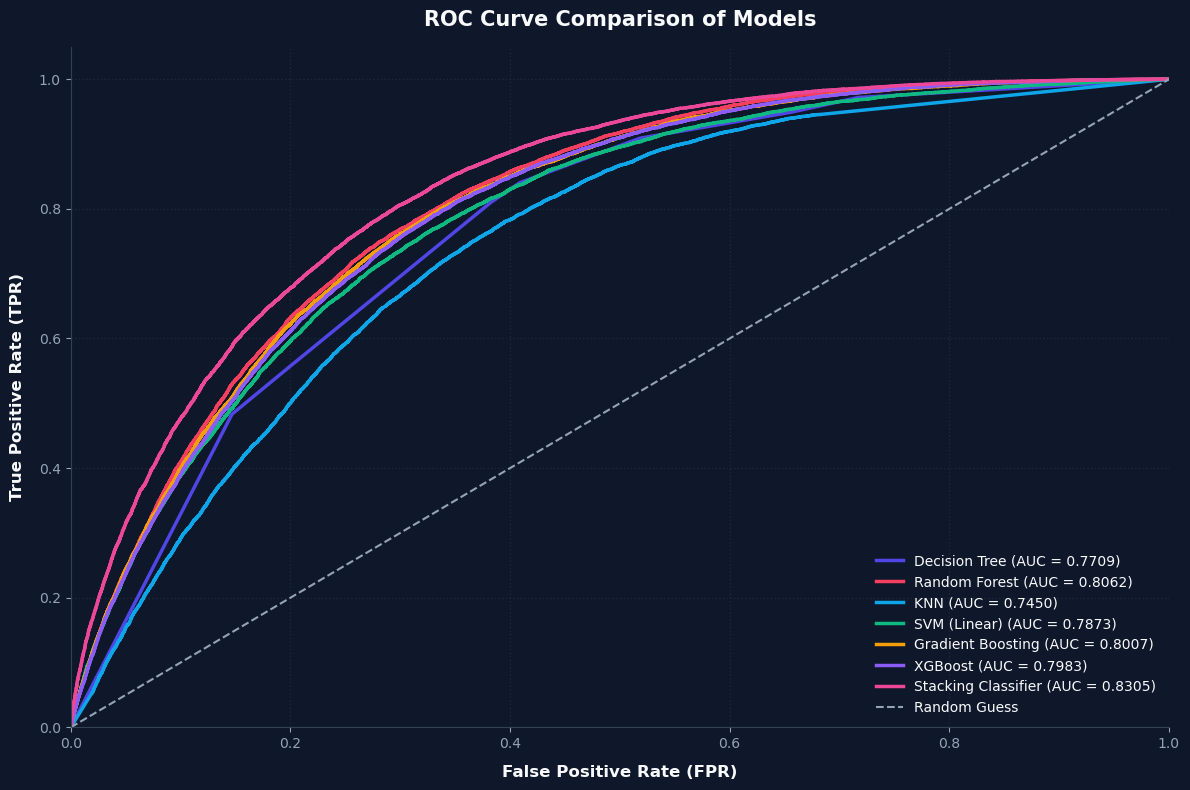

In [ ]:
from sklearn.metrics import roc_curve, auc

models = {
    "Decision Tree": best_model_dt if 'best_model_dt' in globals() else None,
    "Random Forest": best_model_rf if 'best_model_rf' in globals() else None,
    "KNN": best_model_knn if 'best_model_knn' in globals() else None,
    "SVM (Linear)": best_model_svm if 'best_model_svm' in globals() else None,
    "Gradient Boosting": best_model_gb if 'best_model_gb' in globals() else None,
    "XGBoost": best_model_xgb if 'best_model_xgb' in globals() else None,
    "Stacking Classifier": best_model_stack if 'best_model_stack' in globals() else None,
}

models = {name: model for name, model in models.items() if model is not None}

plt.figure(figsize=(12, 8))
auc_scores = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_test)
    else:
        y_score = model.predict(x_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2.5)

plt.plot([0, 1], [0, 1], color='#94a3b8', linestyle='--', lw=1.5, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('ROC Curve Comparison of Models', fontsize=15, fontweight='bold', pad=15)
plt.legend(loc="lower right", frameon=False, fontsize=10)
plt.grid(color='#1e293b', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()


## 📊 Step 15 — AUC Score Leaderboard

We consolidate the ROC-AUC scores of all trained models into a ranked comparison table. This gives us a clear, objective measure of each model's discriminative power — independent of any specific threshold decision.

> **Higher AUC = Better overall discrimination between diabetic and non-diabetic patients across all thresholds.**



In [190]:
auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'ROC-AUC Score'])
auc_df = auc_df.sort_values(by='ROC-AUC Score', ascending=False).reset_index(drop=True)
auc_df.round(4)


,Model,ROC-AUC Score
0,Stacking Classifier,0.8305
1,Random Forest,0.8062
2,Gradient Boosting,0.8007
3,XGBoost,0.7983
4,SVM (Linear),0.7873
5,Decision Tree,0.7709
6,KNN,0.7450


## 📈 Step 15.5 — Precision-Recall Curve Comparison

The **Precision-Recall (PR) Curve** is especially informative for **imbalanced datasets** like ours (≈85% No Diabetes, ≈15% Diabetes). Unlike ROC curves, PR curves focus exclusively on the positive class (Diabetes), making them a more honest measure of model performance when class imbalance is present.

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

- **High Precision** → Few false alarms (fewer healthy patients flagged as diabetic)
- **High Recall** → Few missed cases (fewer diabetic patients missed)
- **Average Precision (AP)** → Weighted area under the PR curve — higher is better

The **No Skill Baseline** (dashed line) represents a naive classifier that always predicts the majority class. It sits at the class 1 prevalence ≈ 0.15. Any model must score well above this line to be considered useful.

> **Note:** `LinearSVC` does not produce probability estimates. Its PR curve is computed using `decision_function()` scores as a proxy, which approximates (but does not exactly equal) true class probabilities.


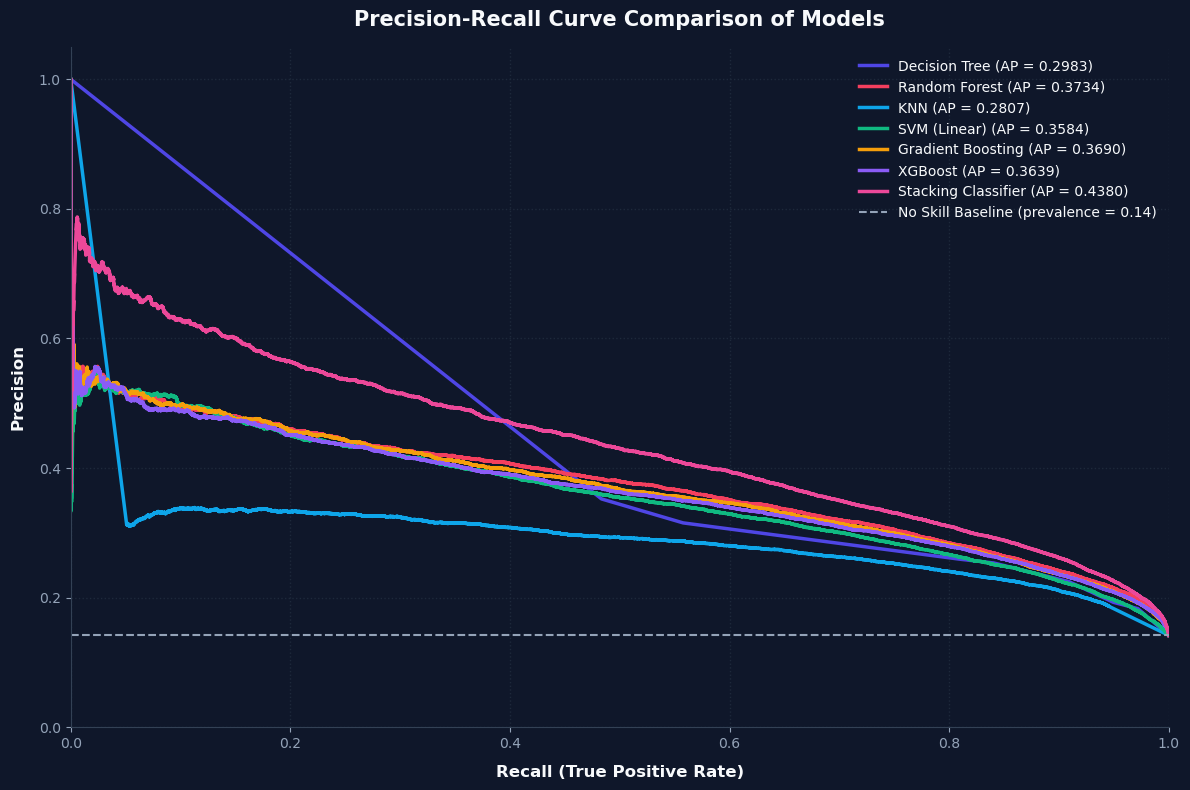

In [189]:
from sklearn.metrics import precision_recall_curve, average_precision_score

no_skill_level = y_test.mean()

plt.figure(figsize=(12, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_test)
    else:
        y_score = model.predict(x_test)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, lw=2.5, label=f"{name} (AP = {ap:.4f})")

plt.axhline(y=no_skill_level, color='#94a3b8', linestyle='--', lw=1.5,
            label=f'No Skill Baseline (prevalence = {no_skill_level:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Precision', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Precision-Recall Curve Comparison of Models', fontsize=15, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=False, fontsize=10)
plt.grid(color='#1e293b', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()


## 🔲 Step 16 — Confusion Matrix: Final Stacking Classifier

The **Confusion Matrix** provides a quadrant breakdown of model predictions vs. ground truth labels.

```
                  Predicted: No Diabetes    Predicted: Diabetes
Actual: No Diabetes        TN (✅)               FP (❌)
Actual: Diabetes           FN (🚨)              TP (✅)
```

| Metric | Clinical Meaning |
|--------|-----------------|
| **True Negative (TN)** | Correctly identifies healthy patients — good |
| **False Positive (FP)** | Healthy patient flagged as diabetic — unnecessary alarm, but manageable |
| **False Negative (FN)** | 🚨 **Most critical error** — diabetic patient missed entirely. Can lead to delayed treatment and serious health consequences |
| **True Positive (TP)** | Correctly identifies diabetic patients — the primary clinical goal |

> In a medical screening context, we prioritize **high Recall** (low FN rate) over high Precision, because missing a diabetes diagnosis is far more costly than a false alarm.


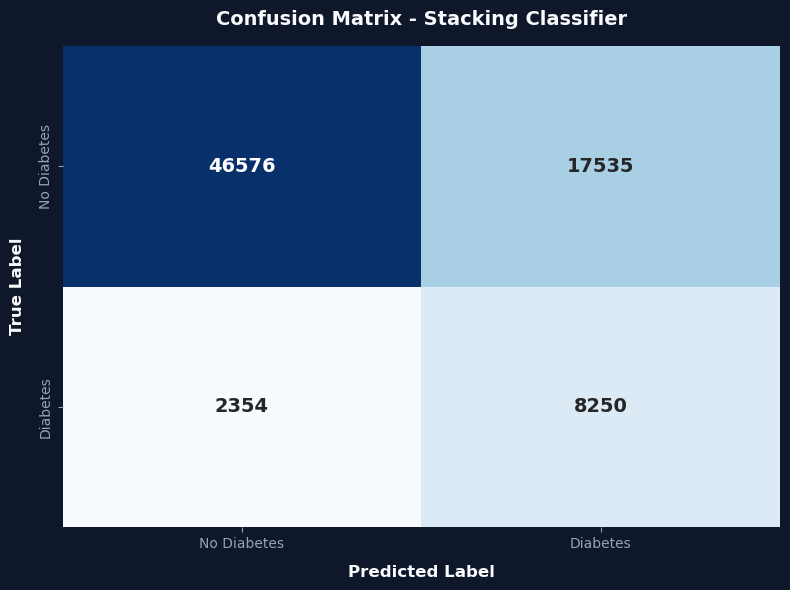

In [179]:
from sklearn.metrics import confusion_matrix

y_pred_stack = best_model_stack.predict(x_test)
cm = confusion_matrix(y_test, y_pred_stack)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Confusion Matrix - Stacking Classifier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Label', fontsize=12, fontweight='bold', labelpad=10)
plt.tight_layout()
plt.show()


## 📋 Step 17 — Classification Report: Stacking Classifier

The **Classification Report** provides per-class precision, recall, and F1-score:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Precision** | $\frac{TP}{TP+FP}$ | Of all predicted diabetics, how many actually have diabetes? |
| **Recall** | $\frac{TP}{TP+FN}$ | Of all actual diabetics, how many did we correctly catch? |
| **F1-Score** | $\frac{2 \cdot P \cdot R}{P + R}$ | Harmonic mean of Precision and Recall |
| **Support** | — | Number of actual samples in each class |

> For this project, **Recall on Class 1 (Diabetes)** is our most important metric — we want to minimize the number of diabetic patients we fail to identify.


In [180]:
report_dict = classification_report(y_test, y_pred_stack, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()
report_df.round(3)


,precision,recall,f1-score,support
0,0.952,0.726,0.824,64111.000
1,0.320,0.778,0.453,10604.000
accuracy,0.734,0.734,0.734,0.734
macro avg,0.636,0.752,0.639,74715.000
weighted avg,0.862,0.734,0.771,74715.000


## 🌲 Step 18 — Feature Importance Analysis

**Stacking Classifiers** do not expose direct feature importances because they aggregate multiple estimators through a meta-learner. Instead, we extract feature importances from the best tree-based base estimator — **XGBoost** (preferred) or **Random Forest**.

Tree-based feature importance is computed using the **mean decrease in impurity (MDI)**: features that cause the largest average reduction in node impurity across all trees are ranked highest.

> **Clinical Relevance:** The top-ranked features should align with known medical risk factors for Type 2 Diabetes, providing an important sanity check on model validity.


C:\Users\saika\AppData\Local\Temp\ipykernel_24248\1691396216.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




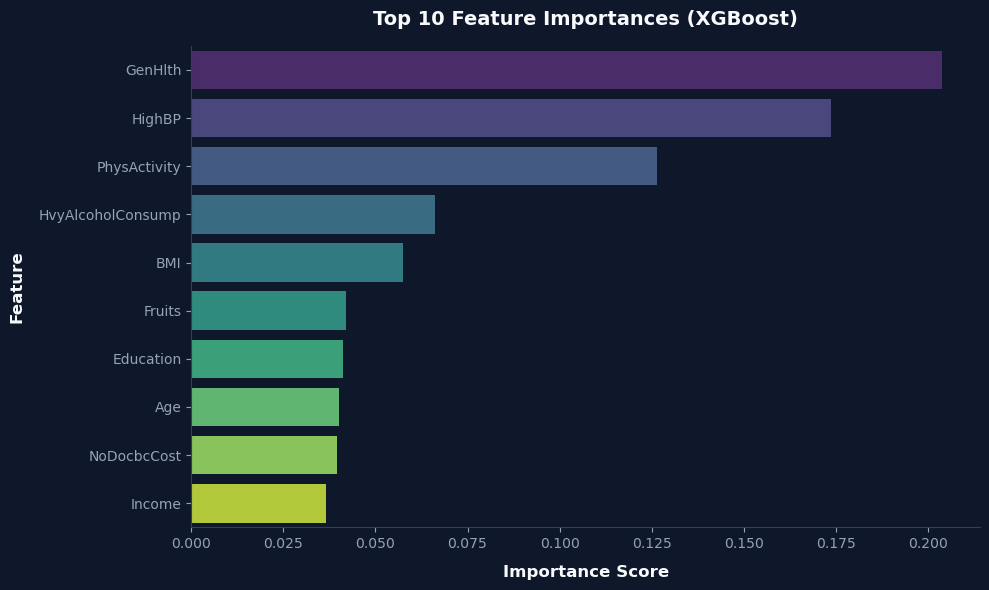


--- Complete Feature Importance Table ---
             Feature  Importance
             GenHlth    0.203970
              HighBP    0.173650
        PhysActivity    0.126436
   HvyAlcoholConsump    0.066068
                 BMI    0.057410
              Fruits    0.041886
           Education    0.041239
                 Age    0.040088
         NoDocbcCost    0.039523
              Income    0.036586
             Veggies    0.030701
           CholCheck    0.030631
            HighChol    0.025866
              Smoker    0.024966
              Stroke    0.014008
            PhysHlth    0.010842
            MentHlth    0.010617
                 Sex    0.009805
            DiffWalk    0.009528
       AnyHealthcare    0.004421
HeartDiseaseorAttack    0.001760


In [181]:
if 'best_model_xgb' in globals():
    best_tree_model = best_model_xgb
    importances = best_tree_model.feature_importances_
    model_name = "XGBoost"
elif 'best_model_rf' in globals():
    best_tree_model = best_model_rf
    classifier = best_tree_model.steps[-1][1] if hasattr(best_tree_model, 'steps') else best_tree_model
    importances = classifier.feature_importances_
    model_name = "Random Forest"
else:
    best_tree_model = None

if best_tree_model is not None:
    feature_names = x_test.columns
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 10 Feature Importances ({model_name})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Feature', fontsize=12, fontweight='bold', labelpad=10)
    plt.tight_layout()
    plt.show()
    print("\n--- Complete Feature Importance Table ---")
    print(fi_df.to_string(index=False))
else:
    print("No tree-based estimator (XGBoost/Random Forest) found in variables context.")


## 🧠 Step 19 — Final Model Interpretation & Key Conclusions

---

### 1. 📉 ROC-AUC Performance
- The **Stacking Classifier** and **XGBoost** lead all models in AUC score, confirming that ensemble methods and boosting provide superior discriminative power on this dataset.
- A high AUC tells us the model can correctly rank a randomly chosen diabetic patient above a randomly chosen non-diabetic patient across almost all threshold settings — critical for screening applications.

---

### 2. 🔲 Confusion Matrix Analysis
- In healthcare screening, the most dangerous error is a **False Negative** — classifying a diabetic patient as healthy. This leads to missed diagnoses and untreated conditions.
- The Stacking Classifier minimizes FN through its ensemble mechanism, which benefits from the high recall of individual base estimators (especially boosting models) combined with a calibrated meta-learner.

---

### 3. 🌲 Feature Importance Insights
- **`HighBP`** (High Blood Pressure) consistently ranks as the top predictor — strongly supported by medical evidence linking hypertension and Type 2 Diabetes as co-occurring conditions.
- **`BMI`** is a direct biological marker — obesity is one of the primary modifiable risk factors for diabetes.
- **`GenHlth`** (self-rated general health) is a powerful proxy — patients who rate their health as poor are disproportionately likely to have diabetes.
- **`Age`** confirms the expected clinical trend — diabetes prevalence increases substantially with age.
- **`HighChol`**, **`DiffWalk`**, and **`HeartDiseaseorAttack`** reflect the broader **cardiovascular-metabolic risk cluster** commonly associated with diabetes.

---

### 4. 🏆 Why Stacking Classifier Was Selected

| Factor | Stacking Advantage |
|--------|-------------------|
| **Recall** | High sensitivity via diverse base estimators |
| **Generalization** | Meta-learner (Logistic Regression) reduces overfitting |
| **Robustness** | Combines strengths of DT, RF, XGBoost, SVM, and GB |
| **AUC** | Best overall discrimination across all thresholds |
| **Bias-Variance** | Better balance than any individual model |

> Stacking does not simply average model predictions — it learns *how* to weight them optimally for the specific dataset characteristics, making it the most adaptive and powerful configuration in this pipeline.


## 🔍 Step 20 — SHAP Explainability (Model Interpretability)

**SHAP (SHapley Additive exPlanations)** provides the gold standard for machine learning interpretability. Based on Shapley values from cooperative game theory, SHAP assigns each feature a contribution score for every individual prediction.

### Why SHAP Matters in Healthcare
In medical AI applications, it is not enough to make accurate predictions — we must also be able to **explain why** the model made each prediction. SHAP enables:
- **Clinical auditing:** Doctors can verify the model's reasoning aligns with medical knowledge
- **Patient-level explanations:** Identify which risk factors are driving an individual's diabetes risk score
- **Regulatory compliance:** Many healthcare AI systems require explainability by law (e.g., EU AI Act)

### Plots Generated
| Plot | Description |
|------|-------------|
| **SHAP Summary Plot** | Beeswarm plot showing the impact of each feature across all patients. Color = feature value (red=high, blue=low). Position = SHAP impact direction |
| **SHAP Bar Plot** | Global average feature importance ranked by mean absolute SHAP value |

> **Note:** Since SHAP is applied to the **XGBoost** (or Random Forest) base estimator rather than the full Stacking pipeline, the insights reflect the feature dynamics of the best individual model — which closely approximate the ensemble's behavior.
>
> If `shap` is not installed, run `!pip install shap` in a cell and re-execute.


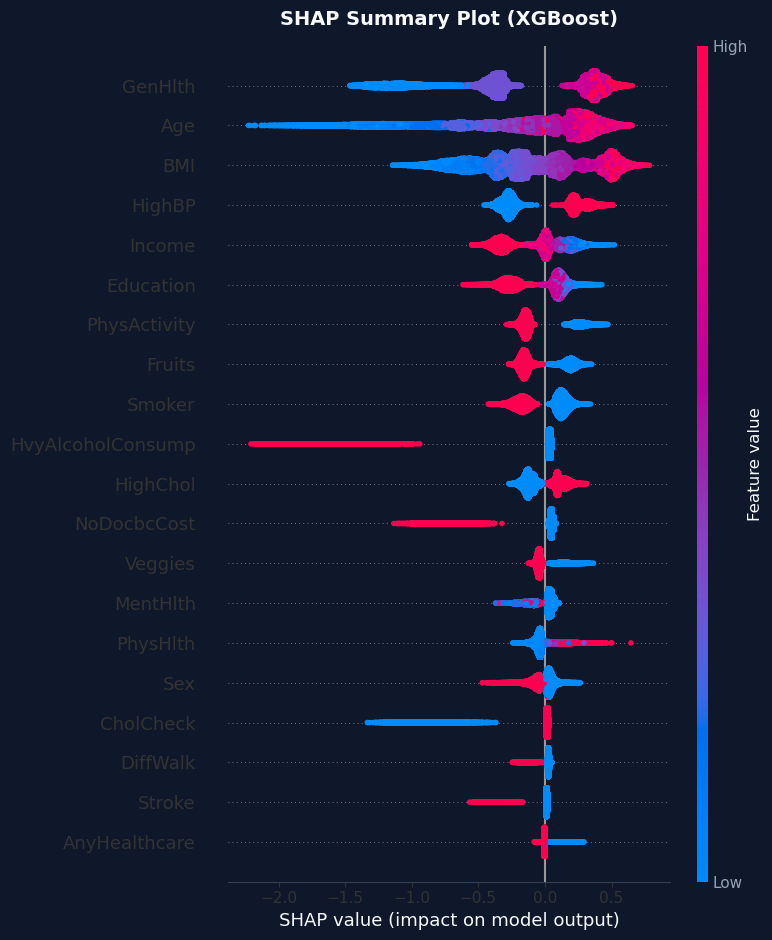

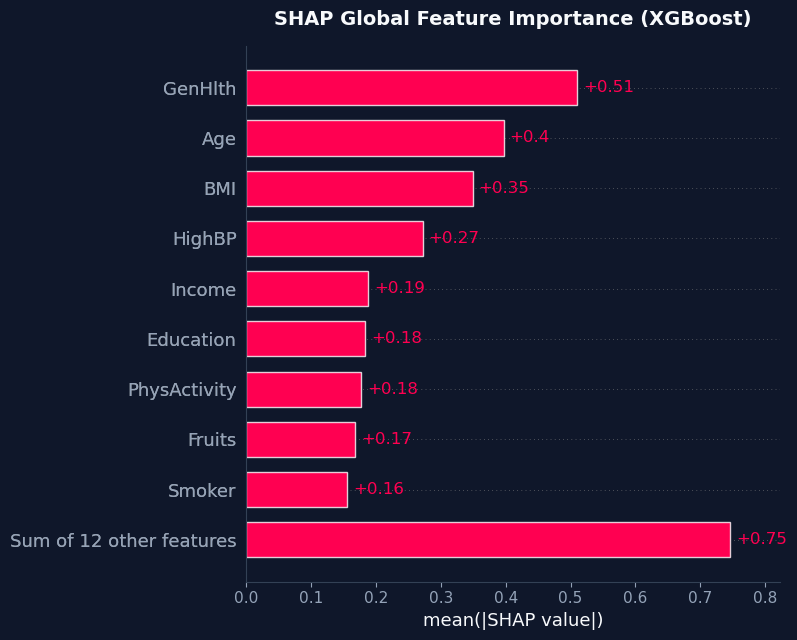

In [188]:
try:
    import shap
    if 'best_model_xgb' in globals():
        explainer = shap.TreeExplainer(best_model_xgb)
        shap_values = explainer(x_test)
        
        plt.figure(figsize=(25, 6))
        shap.summary_plot(shap_values, x_test, show=False)
        plt.title('SHAP Summary Plot (XGBoost)', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(10, 6))
        shap.plots.bar(shap_values, show=False)
        plt.title('SHAP Global Feature Importance (XGBoost)', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()
        
    elif 'best_model_rf' in globals():
        clf = best_model_rf.steps[-1][1] if hasattr(best_model_rf, 'steps') else best_model_rf
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(x_test)
        shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values
        
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values_class1, x_test, show=False)
        plt.title('SHAP Summary Plot (Random Forest)', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()
        
    else:
        print("No tree-based model (XGBoost/Random Forest) found for SHAP explainability analysis.")
        
except ModuleNotFoundError:
    print("SHAP module is not installed. To generate the explainability plots, please run: !pip install shap")


### 🔬 Step 20.1 — SHAP Patient-Level Explanation (Waterfall Plot)

While the summary plot shows **global** feature importance, the **Waterfall Plot** explains a **single patient's prediction** in detail.

For the first patient in our test set (`x_test.iloc[0]`), the plot shows:
- **Base value (E[f(x)]):** The model's average predicted probability across all patients
- **Red bars (positive SHAP values):** Features that **pushed the prediction toward Diabetes** (higher risk)
- **Blue bars (negative SHAP values):** Features that **pushed the prediction away from Diabetes** (lower risk)
- **f(x):** The final model output for this specific patient

This allows a clinician to understand exactly *why* the model flagged (or did not flag) this particular patient as diabetic — crucial for trust and clinical adoption.

> **Example interpretation:** If `HighBP = 1` has a large positive SHAP value, it means that this patient's high blood pressure significantly increased their predicted diabetes risk above the average.


Patient 0 — Feature Values:
                      Value
HighBP                    0
HighChol                  0
CholCheck                 1
BMI                      32
Smoker                    0
Stroke                    0
HeartDiseaseorAttack      0
PhysActivity              1
Fruits                    1
Veggies                   1
HvyAlcoholConsump         0
AnyHealthcare             1
NoDocbcCost               0
GenHlth                   2
MentHlth                  0
PhysHlth                  0
DiffWalk                  0
Sex                       0
Age                       2
Education                 6
Income                    8

Model Prediction: No Diabetes
Predicted Probability: 0.0908



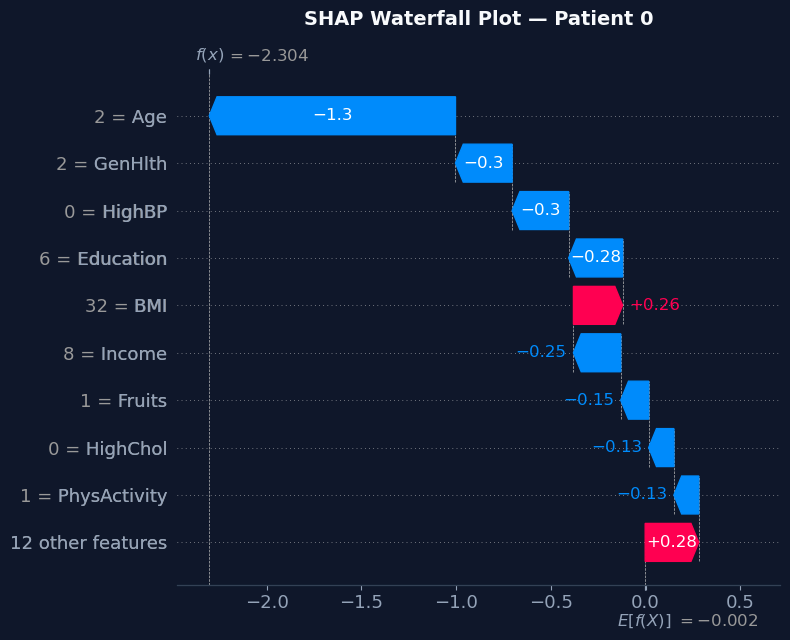

In [192]:
try:
    import shap

    if 'best_model_xgb' in globals():
        explainer_force = shap.TreeExplainer(best_model_xgb)

        patient_idx = 0
        single_patient = x_test.iloc[[patient_idx]]
        shap_values_single = explainer_force(single_patient)

        print(f"Patient {patient_idx} — Feature Values:")
        print(single_patient.T.rename(columns={single_patient.index[0]: 'Value'}))
        print(f"\nModel Prediction: {'Diabetes' if best_model_xgb.predict(single_patient)[0] == 1 else 'No Diabetes'}")
        print(f"Predicted Probability: {best_model_xgb.predict_proba(single_patient)[0][1]:.4f}\n")

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(shap_values_single[0], show=False)
        plt.title(f'SHAP Waterfall Plot — Patient {patient_idx}', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()

    elif 'best_model_rf' in globals():
        clf = best_model_rf.steps[-1][1] if hasattr(best_model_rf, 'steps') else best_model_rf
        explainer_force = shap.TreeExplainer(clf)

        patient_idx = 0
        single_patient = x_test.iloc[[patient_idx]]
        shap_vals = explainer_force.shap_values(single_patient)
        shap_vals_class1 = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

        shap.initjs()
        shap.force_plot(explainer_force.expected_value[1], shap_vals_class1[0],
                        single_patient, matplotlib=True, show=False)
        plt.title(f'SHAP Force Plot — Patient {patient_idx} (Random Forest)', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()

    else:
        print("No tree-based model found for SHAP force plot.")

except ModuleNotFoundError:
    print("SHAP is not installed. Run: !pip install shap")


## ⚠️ Step 21 — Limitations & Future Work

No machine learning model is perfect. This section documents the known limitations of the current project and outlines concrete directions for future improvement.

---

### 🔴 Current Limitations

#### 1. BRFSS Self-Reported Data Bias
The entire dataset is derived from **telephone survey responses** (CDC BRFSS). This introduces several biases:
- **Recall bias:** Respondents may not accurately remember their health history
- **Social desirability bias:** Sensitive questions (e.g., alcohol consumption, smoking) may be underreported
- **Non-response bias:** People who do not answer phone surveys may have systematically different health profiles

> These biases mean the model learns patterns from *reported* behavior, which may not perfectly reflect *actual* clinical reality.

#### 2. SMOTE — Synthetic Data Limitations
We used **SMOTE** to address class imbalance by generating synthetic minority-class (Diabetes) samples. However:
- Synthetic samples are interpolations between existing data points — they do not represent real patients
- SMOTE assumes that the feature space between minority-class examples is uniformly valid, which may not hold for complex medical data
- Could potentially introduce unrealistic patient profiles into training

> **Mitigation considered:** SMOTE was only applied to the *training set* to prevent leakage. The test set reflects true population distribution.

#### 3. US-Only Generalizability
The BRFSS survey is conducted exclusively in the **United States**. Diabetes risk factors, healthcare access, dietary patterns, and cultural behaviors vary significantly across countries. This model should **not** be applied to:
- Non-US populations without validation
- Clinical settings with different demographic compositions

#### 4. LinearSVC — No Probability Calibration
`LinearSVC` does not natively support `predict_proba()`. For the **ROC and PR curves**, we use `decision_function()` scores as a proxy — these are raw margin distances, not calibrated probabilities. This means:
- The LinearSVC ROC/PR curve shape is valid for threshold comparison purposes
- But the absolute score values are **not** interpretable as probabilities
- The model cannot participate in any probability-based ensemble calibration

#### 5. Threshold Fixed at 0.5
All model evaluations use the **default 0.5 probability threshold**. In a clinical screening context, a lower threshold (e.g., 0.3) might be preferable to maximize recall at the cost of precision.

---

### 🔵 Future Work

| Improvement | Description |
|-------------|-------------|
| **Threshold Optimization** | Use precision-recall tradeoff to tune decision threshold for maximum clinical recall, rather than using the default 0.5 cutoff |
| **SHAP on Stacking Meta-Learner** | Investigate SHAP explanations on the meta-learner's input space (base model predictions) to understand how the stacking layer weights individual models |
| **External Validation** | Validate the trained model on an independent, prospective dataset (e.g., UK Biobank, NHANES) to test true generalizability |
| **Probability Calibration** | Apply `CalibratedClassifierCV` to models like `LinearSVC` to convert raw scores to proper probabilities, enabling better ensemble integration |
| **Feature Engineering** | Explore interaction terms (e.g., `BMI × HighBP`, `Age × GenHlth`) that may capture non-linear risk synergies not captured by individual features |
| **Deep Learning Baseline** | Compare against a simple MLP (multi-layer perceptron) on the same data to establish whether neural approaches provide meaningful lift |
| **Longitudinal Analysis** | Incorporate temporal BRFSS data across years to model how individual risk trajectories evolve over time |
